# Matched q=3/2 HJB with Final-Only OOS Validation

This notebook is the single-file Colab version of the nonlinear price-impact experiment with q = 3/2.

The controlled position is dollar exposure

```text
x_t = S_t^0 varphi_t
v_t = dot(x_t)
```

where `varphi_t` is the number of shares. The latest model is

```text
dS_t^0 = mu S_t^0 dt + sigma S_t^0 dB_t
dx_t = v_t dt + x_t (mu dt + sigma dB_t)
dW_t = (mu x_t - (lambda_impact/q) |v_t|^q,  q=3/2) dt
       + sigma x_t dB_t + beta_perp dB_t^perp
varphi_t = x_t / S_t^0
```

The nonlinear power-impact penalty is charged on the rate of change of dollar exposure.
Consequently the frictionless Merton target is the constant dollar exposure
`x^M = mu / (gamma sigma^2)`. In this version `beta_perp=0`, so there is no
independent nontraded endowment shock.

The plots compare a smooth inactive price-impact benchmark against an active
CVaR feedback policy.  The local action grid for `u` is very fine near zero,
so the active trading-rate path is much smoother than the earlier coarse-grid
plots.


## 1. Imports

Run this cell first.  The notebook only needs NumPy and Matplotlib.

In [ ]:
from dataclasses import replace
import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})


## 2. Numerical Solver

Run this once before the settings cell.  It contains the full price-impact
feedback-control machinery used by the plot cells below.

In [ ]:
"""Single-file CVaR-constrained stochastic control prototype.

This file contains everything needed to test the algorithms from
``Projects_AH_XS.pdf`` for a price-impact version of the terminal loss

    ell(W_T) = -W_T.

The state is (W_t, x_t), where x_t=S_t^0*varphi_t is dollar exposure,
and the control is v_t=dot(x_t):

    dx_t = (v_t + mu_t*x_t)dt + sigma_t*x_t dB_t,
    dW_t = (mu_t x_t - (impact_lambda / q) * |v_t|^q) dt
           + sigma_t x_t dB_t.

For backward compatibility, the implementation stores x in variables
named phi and v in variables named trade_rate.

Here mu_t = mu and sigma_t = sigma are constant, so the Bellman state remains
(W_t, varphi_t).

It includes:
  * a 2D inner control kernel for fixed (lambda, eta),
  * Algorithm 1: eta bisection,
  * Algorithm 2: outer lambda bisection,
  * named test cases,
  * an HTML visualization for active and inactive CVaR constraints.

Dependency:
  * numpy

Example commands:
  python cvar_cloud_single_file.py solve --cvar-limit -0.913 --samples 250 --steps 12
  python cvar_cloud_single_file.py cases --case all
  python cvar_cloud_single_file.py plot
  python cvar_cloud_single_file.py policy --case active
  python cvar_cloud_single_file.py trajectory --case active --sample-index 0
  python cvar_cloud_single_file.py visualize --output cvar_visualization.html
"""

from __future__ import annotations

IMPACT_Q = 1.5  # q = 3/2 in (Lambda/(q*S^(3/2))) |v|^(3/2)


from dataclasses import dataclass, replace
from html import escape
from pathlib import Path
import argparse
import json
import math
import sys
import time
from typing import Optional

import numpy as np


@dataclass(frozen=True)
class ModelParams:
    """Scalar model and numerical parameters."""

    horizon: float = 1.0
    steps: int = 200
    samples: int = 2_000
    seed: int = 7

    # Dollar-exposure linear-impact dynamics (legacy names: phi=x, u=v):
    # dS^0 = mu_t*S^0 dt + sigma_t*S^0 dB,
    # dx = v dt,
    # dW = (mu_t*x - (impact_lambda/q)*|v|^q)dt + sigma_t*x dB.
    w0: float = 1.0
    mu: float = 0.08
    sigma: float = 0.20
    phi0: float = 0.0
    impact_lambda: float = 0.10

    # Legacy deterministic market-shape parameters kept for CLI compatibility.
    # The current price-impact experiment uses constant mu_t = mu and
    # sigma_t = sigma, so these are set to zero and ignored below.
    alpha0: float = 0.00
    alpha_decay: float = 2.0
    drift_cycle_amp: float = 0.00
    drift_cycle_freq: float = 1.0
    drift_cycle_phase: float = 0.0
    vol_trend: float = 0.00
    vol_cycle_amp: float = 0.00
    vol_cycle_freq: float = 1.0
    vol_cycle_phase: float = 0.4
    vol_pulse_amp: float = 0.00
    vol_pulse_center: float = 0.65
    vol_pulse_width: float = 0.18
    vol_floor: float = 0.05

    # Kept for compatibility with older helper functions/CLI output.
    r: float = 0.00
    b: float = 0.00
    beta_perp: float = 0.02

    # Objective:
    # E int [0.5*gamma*(sigma*phi_t)^2 - mu*phi_t
    #        + (impact_lambda/q)*|u_t|^q] dt.
    # The terminal cost is g(W_T) = 0. q_w, q_phi, q_terminal, and
    # terminal_target are kept for CLI compatibility, but are not used by the
    # current f and g.
    gamma: float = 5.0
    q_w: float = 0.02
    q_phi: float = 0.05
    q_terminal: float = 1.0
    terminal_target: float = 1.25

    # Inventory state bounds phi in [phi_min, phi_max].
    phi_min: float = -2.0
    phi_max: float = 2.0
    # Trading-rate control bounds u = dot(phi) in [trade_min, trade_max].
    trade_min: float = -4.0
    trade_max: float = 4.0

    # CVaR_alpha(ell(W_T)) <= c.
    alpha: float = 0.95
    cvar_limit: float = -0.70

    # Optimization tolerances.
    control_max_iter: int = 90
    control_grad_tol: float = 2.0e-4
    eta_tol: float = 8.0e-4
    eta_subgrad_tol: float = 6.0e-4
    lambda_tol: float = 8.0e-4
    residual_tol: float = 1.0e-3
    eta_max_iter: int = 16
    lambda_max_iter: int = 18
    lambda_initial_high: float = 1.0
    lambda_high_cap: float = 1.0e5

    # Inner control solver. "value_iteration" gives a closed-loop Markov
    # feedback policy phi_n(W_n); "open_loop_pg" keeps the older projected
    # gradient solver over deterministic piecewise-constant controls.
    control_solver: str = "value_iteration"
    state_grid_size: int = 61
    inventory_grid_size: int = 31
    action_grid_size: int = 31
    action_dense_width: float = 0.75
    action_outer_count: int = 9
    bellman_shock_count: int = 3
    state_grid_padding: float = 0.25


@dataclass
class ControlResult:
    phi: np.ndarray
    eta: float
    objective: float
    lagrangian: float
    residual: float
    cvar: float
    var: float
    mean_terminal_wealth: float
    terminal_wealth_std: float
    loss_tail_probability: float
    iterations: int
    grad_norm: float
    policy_grid: Optional[np.ndarray] = None
    wealth_grid: Optional[np.ndarray] = None
    inventory_grid: Optional[np.ndarray] = None
    terminal_wealth: Optional[np.ndarray] = None
    loss: Optional[np.ndarray] = None
    phi_paths: Optional[np.ndarray] = None
    trade_rate: Optional[np.ndarray] = None
    trade_rate_paths: Optional[np.ndarray] = None


@dataclass
class VisualCaseResult:
    name: str
    params: ModelParams
    lambda_star: float
    eta_star: float
    objective: float
    cvar: float
    var: float
    residual: float
    terminal_wealth: np.ndarray
    loss: np.ndarray
    phi: np.ndarray
    elapsed_seconds: float
    oracle_calls: int
    trade_rate: Optional[np.ndarray] = None
    phi_paths: Optional[np.ndarray] = None
    trade_rate_paths: Optional[np.ndarray] = None
    policy_grid: Optional[np.ndarray] = None
    wealth_grid: Optional[np.ndarray] = None
    inventory_grid: Optional[np.ndarray] = None


def generate_brownian_increments(params: ModelParams) -> np.ndarray:
    rng = np.random.default_rng(params.seed)
    dt = params.horizon / params.steps
    return rng.normal(0.0, math.sqrt(dt), size=(params.samples, params.steps))


def time_point(step: int, params: ModelParams) -> float:
    """Left endpoint time for Euler/Bellman step."""

    return params.horizon * step / params.steps


def market_drift(step: int, params: ModelParams) -> float:
    """Constant stock drift mu_t = mu."""

    return params.mu


def market_volatility(step: int, params: ModelParams) -> float:
    """Constant stock volatility sigma_t = sigma."""

    return max(params.vol_floor, params.sigma)


def market_drift_grid(params: ModelParams) -> np.ndarray:
    return np.array([market_drift(n, params) for n in range(params.steps)])


def market_volatility_grid(params: ModelParams) -> np.ndarray:
    return np.array([market_volatility(n, params) for n in range(params.steps)])


def smooth_inactive_frictional_policy(params: ModelParams) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Closed-form inactive price-impact path for constant mu and sigma.

    This solves the lambda*=0 deterministic variational problem

        min int [0.5*gamma*sigma^2*varphi^2 - mu*varphi
                 + (impact_lambda/q)*|u|^q] dt,

    with varphi(0)=phi0 and natural terminal condition u(T)=0.
    """

    time_grid = np.linspace(0.0, params.horizon, params.steps + 1)
    control_time = time_grid[:-1]
    a = params.gamma * max(params.sigma, params.vol_floor) ** 2
    if params.impact_lambda <= 1.0e-14 or a <= 1.0e-14:
        target = params.mu / max(a, 1.0e-14)
        phi = np.full(params.steps + 1, np.clip(target, params.phi_min, params.phi_max))
        phi[0] = params.phi0
        u = np.diff(phi) / (params.horizon / params.steps)
        return time_grid, phi, np.clip(u, params.trade_min, params.trade_max)

    target = params.mu / a
    kappa = math.sqrt(a / params.impact_lambda)
    denom = math.cosh(kappa * params.horizon)
    phi = target + (params.phi0 - target) * np.cosh(
        kappa * (params.horizon - time_grid)
    ) / denom
    u = -(params.phi0 - target) * kappa * np.sinh(
        kappa * (params.horizon - control_time)
    ) / denom
    phi = np.clip(phi, params.phi_min, params.phi_max)
    u = np.clip(u, params.trade_min, params.trade_max)
    return time_grid, phi, u


def simulate_price_impact_paths(
    trade_rate: np.ndarray,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Euler simulation for the price-impact model.

    ``trade_rate`` is the control u_n = dot(varphi_n). The risky position
    varphi_n is a state variable with initial value params.phi0.
    """

    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    trade_rate = np.asarray(trade_rate, dtype=float)
    if trade_rate.ndim == 1:
        if trade_rate.shape[0] != steps:
            raise ValueError(f"Expected {steps} trade-rate steps, got {trade_rate.shape[0]}.")
        trade_rate_paths = np.broadcast_to(trade_rate, (samples, steps)).copy()
    elif trade_rate.shape == (samples, steps):
        trade_rate_paths = trade_rate.copy()
    else:
        raise ValueError(
            "trade_rate must have shape (steps,) or (samples, steps); "
            f"got {trade_rate.shape}."
        )
    trade_rate_paths = np.clip(trade_rate_paths, params.trade_min, params.trade_max)

    wealth = np.empty((samples, steps + 1))
    phi_paths = np.empty((samples, steps + 1))
    wealth[:, 0] = params.w0
    phi_paths[:, 0] = params.phi0

    for n in range(steps):
        d_b = d_brownian[:, n]
        phi_n = phi_paths[:, n]
        u_n = trade_rate_paths[:, n]
        mu_n = market_drift(n, params)
        sigma_n = market_volatility(n, params)
        wealth[:, n + 1] = (
            wealth[:, n]
            + (mu_n * phi_n - params.impact_lambda / IMPACT_Q * np.abs(u_n)**IMPACT_Q) * dt
            + sigma_n * phi_n * d_b
        )
        phi_paths[:, n + 1] = np.clip(
            phi_n + u_n * dt,
            params.phi_min,
            params.phi_max,
        )
    return wealth, phi_paths, trade_rate_paths


def simulate_wealth(
    trade_rate: np.ndarray,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> np.ndarray:
    """Return only the wealth paths for an open-loop trading-rate control."""

    wealth, _, _ = simulate_price_impact_paths(trade_rate, d_brownian, params)
    return wealth


def cvar_from_loss(loss: np.ndarray, alpha: float) -> tuple[float, float]:
    """Return empirical Rockafellar-Uryasev CVaR and VaR."""

    var = float(np.quantile(loss, alpha))
    cvar = float(var + np.maximum(loss - var, 0.0).mean() / (1.0 - alpha))
    return cvar, var


def objective_gradient_and_stats(
    phi: np.ndarray,
    eta: float,
    lambda_value: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[float, float, float, float, np.ndarray, dict[str, float]]:
    """Evaluate L(phi, eta, lambda) and grad_phi L.

    This is the inner-kernel derivative.  It uses a backward adjoint recursion,
    not the full sensitivity tensor dW_t/dphi_k.  Cost per gradient call is
    O(samples * steps).
    """

    wealth = simulate_wealth(phi, d_brownian, params)
    dt = params.horizon / params.steps
    growth = 1.0 + params.r * dt

    terminal_wealth = wealth[:, -1]
    loss = -terminal_wealth
    hinge = np.maximum(loss - eta, 0.0)
    tail_indicator = (loss > eta).astype(float)

    running = dt * np.sum(
        0.5 * params.gamma * (params.sigma * phi) ** 2 - params.mu * phi
    )
    terminal = np.zeros_like(terminal_wealth)
    objective = float(np.mean(running + terminal))
    residual = float(eta + hinge.mean() / (1.0 - params.alpha) - params.cvar_limit)
    lagrangian = objective + lambda_value * residual

    adjoint = np.zeros_like(terminal_wealth)
    if lambda_value != 0.0:
        adjoint -= lambda_value * tail_indicator / (1.0 - params.alpha)

    grad = np.empty_like(phi)
    for n in range(params.steps - 1, -1, -1):
        d_w_next_d_phi = params.mu * dt + params.sigma * d_brownian[:, n]
        grad[n] = dt * (
            params.gamma * params.sigma**2 * phi[n] - params.mu
        ) + np.mean(adjoint * d_w_next_d_phi)
        adjoint = growth * adjoint

    cvar, var = cvar_from_loss(loss, params.alpha)
    stats = {
        "cvar": cvar,
        "var": var,
        "mean_terminal_wealth": float(np.mean(terminal_wealth)),
        "terminal_wealth_std": float(np.std(terminal_wealth)),
        "loss_tail_probability": float(np.mean(loss > eta)),
    }
    return objective, residual, lagrangian, float(np.linalg.norm(grad)), grad, stats


def project_control(phi: np.ndarray, params: ModelParams) -> np.ndarray:
    return np.clip(phi, params.trade_min, params.trade_max)


def projected_gradient_norm(phi: np.ndarray, grad: np.ndarray, params: ModelParams) -> float:
    return float(np.linalg.norm(phi - project_control(phi - grad, params)))


def open_loop_control_kernel(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
    *,
    initial_phi: Optional[np.ndarray] = None,
) -> ControlResult:
    """Older fixed-(lambda, eta) open-loop projected-gradient kernel.

    Solves min_{phi in A} L(phi, eta, lambda) for deterministic
    piecewise-constant open-loop controls.
    """

    raise NotImplementedError(
        "open_loop_pg was written for the older direct-position control model. "
        "Use control_solver='value_iteration' for the price-impact model where "
        "the control is u=dot(varphi) and varphi is a state."
    )

    if initial_phi is None:
        phi = np.zeros(params.steps)
    else:
        phi = project_control(initial_phi.astype(float).copy(), params)

    obj, residual, lag, grad_norm, grad, stats = objective_gradient_and_stats(
        phi, eta, lambda_value, d_brownian, params
    )
    stationarity = projected_gradient_norm(phi, grad, params)

    step_size = 0.5
    accepted_iter = 0
    for iteration in range(1, params.control_max_iter + 1):
        if stationarity <= params.control_grad_tol:
            accepted_iter = iteration - 1
            break

        accepted = False
        local_step = step_size
        for _ in range(12):
            candidate = project_control(phi - local_step * grad, params)
            cand_obj, cand_residual, cand_lag, cand_grad_norm, cand_grad, cand_stats = (
                objective_gradient_and_stats(
                    candidate, eta, lambda_value, d_brownian, params
                )
            )
            cand_stationarity = projected_gradient_norm(candidate, cand_grad, params)
            if cand_lag <= lag - 1.0e-4 * np.dot(grad, phi - candidate):
                phi = candidate
                obj = cand_obj
                residual = cand_residual
                lag = cand_lag
                grad_norm = cand_grad_norm
                grad = cand_grad
                stationarity = cand_stationarity
                stats = cand_stats
                step_size = min(local_step * 1.15, 3.0)
                accepted_iter = iteration
                accepted = True
                break
            local_step *= 0.5

        if not accepted:
            step_size *= 0.5
            if step_size < 1.0e-10:
                accepted_iter = iteration
                break

    terminal_wealth = simulate_wealth(phi, d_brownian, params)[:, -1]
    cvar, var = cvar_from_loss(-terminal_wealth, params.alpha)
    return ControlResult(
        phi=phi,
        eta=eta,
        objective=obj,
        lagrangian=lag,
        residual=residual,
        cvar=cvar,
        var=var,
        mean_terminal_wealth=stats["mean_terminal_wealth"],
        terminal_wealth_std=stats["terminal_wealth_std"],
        loss_tail_probability=stats["loss_tail_probability"],
        iterations=accepted_iter,
        grad_norm=grad_norm,
        terminal_wealth=terminal_wealth,
        loss=-terminal_wealth,
    )


def running_cost(
    phi: np.ndarray | float,
    trade_rate: np.ndarray | float,
    params: ModelParams,
    step: int,
) -> np.ndarray | float:
    """Running cost f(varphi, u) for the price-impact model."""

    mu_t = market_drift(step, params)
    sigma_t = market_volatility(step, params)
    return (
        0.5 * params.gamma * (sigma_t * phi) ** 2
        - mu_t * phi
        + params.impact_lambda / IMPACT_Q * np.abs(trade_rate)**IMPACT_Q
    )


def build_state_grids(d_brownian: np.ndarray, params: ModelParams) -> tuple[np.ndarray, np.ndarray]:
    """Choose wealth and inventory grids from exploratory trading-rate probes."""

    dt = params.horizon / params.steps
    mu_bar = float(np.mean(market_drift_grid(params)))
    sigma_bar = float(np.mean(market_volatility_grid(params)))
    merton_phi = mu_bar / max(params.gamma * sigma_bar**2, 1.0e-12)
    ramp_to_merton = float(np.clip((merton_phi - params.phi0) / params.horizon, params.trade_min, params.trade_max))
    probes = [
        np.zeros(params.steps),
        np.full(params.steps, params.trade_min),
        np.full(params.steps, params.trade_max),
        np.full(params.steps, ramp_to_merton),
    ]

    # Add two turn-around probes so the wealth grid sees both long and short
    # inventories without relying only on monotone trading.
    half = params.steps // 2
    buy_then_sell = np.full(params.steps, params.trade_min)
    buy_then_sell[:half] = params.trade_max
    sell_then_buy = -buy_then_sell
    probes.extend([buy_then_sell, sell_then_buy])

    wealth_paths = []
    phi_paths = []
    for trade_rate in probes:
        wealth, phi, _ = simulate_price_impact_paths(trade_rate, d_brownian, params)
        wealth_paths.append(wealth)
        phi_paths.append(phi)

    wealth = np.concatenate([path.reshape(-1) for path in wealth_paths])
    low = float(np.quantile(wealth, 0.002))
    high = float(np.quantile(wealth, 0.998))
    width = max(high - low, 1.0e-3)
    low -= params.state_grid_padding * width
    high += params.state_grid_padding * width

    phi_seen = np.concatenate([path.reshape(-1) for path in phi_paths])
    phi_low = min(params.phi_min, float(np.min(phi_seen)) - dt * abs(params.trade_min))
    phi_high = max(params.phi_max, float(np.max(phi_seen)) + dt * abs(params.trade_max))
    phi_low = max(phi_low, params.phi_min)
    phi_high = min(phi_high, params.phi_max)

    return (
        np.linspace(low, high, params.state_grid_size),
        np.linspace(phi_low, phi_high, params.inventory_grid_size),
    )


def bellman_shocks(params: ModelParams) -> tuple[np.ndarray, np.ndarray]:
    """Gauss-Hermite quadrature nodes for dB over one time step."""

    nodes, weights = np.polynomial.hermite.hermgauss(params.bellman_shock_count)
    dt = params.horizon / params.steps
    d_b = math.sqrt(2.0 * dt) * nodes
    probs = weights / math.sqrt(math.pi)
    return d_b, probs


def action_grid(params: ModelParams) -> np.ndarray:
    """Trading-rate grid, dense near zero and sparse in the far tails."""

    dense_width = min(
        max(params.action_dense_width, 0.0),
        max(abs(params.trade_min), abs(params.trade_max)),
    )
    dense_low = max(params.trade_min, -dense_width)
    dense_high = min(params.trade_max, dense_width)
    dense = np.linspace(dense_low, dense_high, params.action_grid_size)

    outer_count = max(0, params.action_outer_count)
    pieces = [dense, np.array([0.0, params.trade_min, params.trade_max])]
    if outer_count > 0 and params.trade_min < dense_low:
        pieces.append(np.linspace(params.trade_min, dense_low, outer_count))
    if outer_count > 0 and dense_high < params.trade_max:
        pieces.append(np.linspace(dense_high, params.trade_max, outer_count))

    grid = np.concatenate(pieces)
    grid = np.round(grid, 12)
    grid = np.sort(np.unique(grid))
    return grid[(grid >= params.trade_min - 1.0e-12) & (grid <= params.trade_max + 1.0e-12)]


def interp_value_2d(
    wealth: np.ndarray,
    phi: np.ndarray,
    wealth_grid: np.ndarray,
    inventory_grid: np.ndarray,
    values: np.ndarray,
) -> np.ndarray:
    """Bilinear interpolation with boundary clamping."""

    wealth_clipped = np.clip(wealth, wealth_grid[0], wealth_grid[-1])
    phi_clipped = np.clip(phi, inventory_grid[0], inventory_grid[-1])

    wi = np.searchsorted(wealth_grid, wealth_clipped, side="right") - 1
    pi = np.searchsorted(inventory_grid, phi_clipped, side="right") - 1
    wi = np.clip(wi, 0, wealth_grid.size - 2)
    pi = np.clip(pi, 0, inventory_grid.size - 2)

    w0 = wealth_grid[wi]
    w1 = wealth_grid[wi + 1]
    p0 = inventory_grid[pi]
    p1 = inventory_grid[pi + 1]
    tw = np.divide(wealth_clipped - w0, w1 - w0, out=np.zeros_like(wealth_clipped, dtype=float), where=w1 != w0)
    tp = np.divide(phi_clipped - p0, p1 - p0, out=np.zeros_like(phi_clipped, dtype=float), where=p1 != p0)

    v00 = values[wi, pi]
    v10 = values[wi + 1, pi]
    v01 = values[wi, pi + 1]
    v11 = values[wi + 1, pi + 1]

    return (
        (1.0 - tw) * (1.0 - tp) * v00
        + tw * (1.0 - tp) * v10
        + (1.0 - tw) * tp * v01
        + tw * tp * v11
    )


def fit_feedback_policy(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Finite-horizon value iteration for u_n = pi_n(W_n, varphi_n)."""

    wealth_grid, inventory_grid = build_state_grids(d_brownian, params)
    actions = action_grid(params)
    d_b_nodes, d_b_probs = bellman_shocks(params)
    dt = params.horizon / params.steps

    wealth_mesh, inventory_mesh = np.meshgrid(wealth_grid, inventory_grid, indexing="ij")
    terminal_value = lambda_value * np.maximum(-wealth_grid - eta, 0.0) / (1.0 - params.alpha)
    value_next = np.repeat(terminal_value[:, None], inventory_grid.size, axis=1)
    value_grid = np.empty((params.steps + 1, wealth_grid.size, inventory_grid.size))
    value_grid[-1] = value_next
    policy_grid = np.empty((params.steps, wealth_grid.size, inventory_grid.size))

    for n in range(params.steps - 1, -1, -1):
        mu_n = market_drift(n, params)
        sigma_n = market_volatility(n, params)
        q_values = np.empty((actions.size, wealth_grid.size, inventory_grid.size))
        for a_idx, trade_rate in enumerate(actions):
            next_phi = inventory_mesh + trade_rate * dt
            feasible = (
                (next_phi >= params.phi_min - 1.0e-12)
                & (next_phi <= params.phi_max + 1.0e-12)
            )
            expected_continuation = np.zeros_like(value_next)
            for d_b, prob in zip(d_b_nodes, d_b_probs):
                next_w = (
                    wealth_mesh
                    + (mu_n * inventory_mesh - params.impact_lambda / IMPACT_Q * np.abs(trade_rate)**IMPACT_Q) * dt
                    + sigma_n * inventory_mesh * d_b
                )
                expected_continuation += prob * interp_value_2d(
                    next_w,
                    next_phi,
                    wealth_grid,
                    inventory_grid,
                    value_next,
                )
            q = dt * running_cost(inventory_mesh, trade_rate, params, n) + expected_continuation
            q_values[a_idx] = np.where(feasible, q, np.inf)

        best_idx = np.argmin(q_values, axis=0)
        value_next = np.take_along_axis(q_values, best_idx[None, :, :], axis=0)[0]
        value_grid[n] = value_next
        policy_grid[n] = actions[best_idx]

    return wealth_grid, inventory_grid, policy_grid, value_grid


def simulate_feedback_policy(
    wealth_grid: np.ndarray,
    inventory_grid: np.ndarray,
    policy_grid: np.ndarray,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate W, varphi, and state-dependent trading rates u_n(W_n, varphi_n)."""

    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    wealth = np.empty((samples, steps + 1))
    phi_paths = np.empty((samples, steps + 1))
    trade_rate_paths = np.empty((samples, steps))
    wealth[:, 0] = params.w0
    phi_paths[:, 0] = params.phi0

    for n in range(steps):
        phi_n = phi_paths[:, n]
        trade_rate_n = interp_value_2d(
            wealth[:, n],
            phi_n,
            wealth_grid,
            inventory_grid,
            policy_grid[n],
        )
        trade_rate_n = np.clip(trade_rate_n, params.trade_min, params.trade_max)
        trade_rate_paths[:, n] = trade_rate_n
        mu_n = market_drift(n, params)
        sigma_n = market_volatility(n, params)
        wealth[:, n + 1] = (
            wealth[:, n]
            + (mu_n * phi_n - params.impact_lambda / IMPACT_Q * np.abs(trade_rate_n)**IMPACT_Q) * dt
            + sigma_n * phi_n * d_brownian[:, n]
        )
        phi_paths[:, n + 1] = np.clip(
            phi_n + trade_rate_n * dt,
            params.phi_min,
            params.phi_max,
        )

    return wealth, phi_paths, trade_rate_paths


def feedback_value_iteration_kernel(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> ControlResult:
    """Closed-loop inner kernel using finite-horizon value iteration.

    For fixed (lambda, eta), the Lagrangian subproblem is Markovian in
    (W_n, varphi_n). This routine approximates the Bellman recursion on a
    wealth/inventory grid and returns a feedback trading-rate policy
    u_n = pi_n(W_n, varphi_n), represented by policy_grid[n, w_index, phi_index].
    """

    wealth_grid, inventory_grid, policy_grid, _ = fit_feedback_policy(
        lambda_value, eta, d_brownian, params
    )
    wealth, phi_paths, trade_rate_paths = simulate_feedback_policy(
        wealth_grid, inventory_grid, policy_grid, d_brownian, params
    )

    dt = params.horizon / params.steps
    terminal_wealth = wealth[:, -1]
    loss = -terminal_wealth
    hinge = np.maximum(loss - eta, 0.0)
    phi_on_intervals = phi_paths[:, :-1]
    running = dt * np.sum(
        [
            running_cost(phi_on_intervals[:, n], trade_rate_paths[:, n], params, n)
            for n in range(params.steps)
        ],
        axis=0,
    )
    objective = float(np.mean(running))
    residual = float(eta + hinge.mean() / (1.0 - params.alpha) - params.cvar_limit)
    lagrangian = objective + lambda_value * residual
    cvar, var = cvar_from_loss(loss, params.alpha)

    return ControlResult(
        phi=np.mean(phi_on_intervals, axis=0),
        eta=eta,
        objective=objective,
        lagrangian=lagrangian,
        residual=residual,
        cvar=cvar,
        var=var,
        mean_terminal_wealth=float(np.mean(terminal_wealth)),
        terminal_wealth_std=float(np.std(terminal_wealth)),
        loss_tail_probability=float(np.mean(loss > eta)),
        iterations=params.steps,
        grad_norm=0.0,
        policy_grid=policy_grid,
        wealth_grid=wealth_grid,
        inventory_grid=inventory_grid,
        terminal_wealth=terminal_wealth,
        loss=loss,
        phi_paths=phi_paths,
        trade_rate=np.mean(trade_rate_paths, axis=0),
        trade_rate_paths=trade_rate_paths,
    )


def inner_control_kernel(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
    *,
    initial_phi: Optional[np.ndarray] = None,
) -> ControlResult:
    """Algorithm 0: fixed-(lambda, eta) control oracle.

    Default mode uses value iteration to produce a closed-loop Markov feedback
    trading-rate control u_n(W_n, varphi_n).
    """

    if params.control_solver == "open_loop_pg":
        return open_loop_control_kernel(lambda_value, eta, d_brownian, params, initial_phi=initial_phi)
    if params.control_solver != "value_iteration":
        raise ValueError(f"Unknown control_solver={params.control_solver!r}")
    return feedback_value_iteration_kernel(lambda_value, eta, d_brownian, params)


def eta_bracket(params: ModelParams) -> tuple[float, float]:
    """Conservative compact eta interval for the sample problem."""

    max_phi = max(abs(params.phi_min), abs(params.phi_max), abs(params.phi0))
    max_trade = max(abs(params.trade_min), abs(params.trade_max))
    max_mu = float(np.max(np.abs(market_drift_grid(params))))
    max_sigma = float(np.max(market_volatility_grid(params)))
    drift_bound = (
        abs(params.w0)
        + params.horizon * (max_mu * max_phi + params.impact_lambda / IMPACT_Q * np.abs(max_trade)**IMPACT_Q)
    )
    diffusion_bound = 6.0 * math.sqrt(params.horizon) * max_sigma * max_phi
    bound = max(2.0, drift_bound + diffusion_bound)
    return -bound, bound


def eta_bisection(
    lambda_value: float,
    d_brownian: np.ndarray,
    params: ModelParams,
    *,
    warm_start_phi: Optional[np.ndarray] = None,
) -> ControlResult:
    """Algorithm 1: bisection over eta for fixed lambda > 0."""

    eta_low, eta_high = eta_bracket(params)
    phi_guess = warm_start_phi
    best: Optional[ControlResult] = None

    for _ in range(params.eta_max_iter):
        eta_mid = 0.5 * (eta_low + eta_high)
        result = inner_control_kernel(
            lambda_value,
            eta_mid,
            d_brownian,
            params,
            initial_phi=phi_guess,
        )
        phi_guess = result.phi
        best = result

        subgrad = lambda_value * (
            1.0 - result.loss_tail_probability / (1.0 - params.alpha)
        )
        if abs(subgrad) <= params.eta_subgrad_tol or eta_high - eta_low <= params.eta_tol:
            return result
        if subgrad < 0.0:
            eta_low = eta_mid
        else:
            eta_high = eta_mid

    assert best is not None
    return best


def unconstrained_solution(d_brownian: np.ndarray, params: ModelParams) -> ControlResult:
    result = inner_control_kernel(0.0, 0.0, d_brownian, params)
    if result.terminal_wealth is None:
        terminal_wealth = simulate_wealth(result.phi, d_brownian, params)[:, -1]
        loss = -terminal_wealth
    else:
        terminal_wealth = result.terminal_wealth
        loss = result.loss if result.loss is not None else -terminal_wealth
    cvar, var = cvar_from_loss(loss, params.alpha)
    residual = cvar - params.cvar_limit
    return replace(
        result,
        eta=var,
        residual=residual,
        cvar=cvar,
        var=var,
        loss_tail_probability=float(np.mean(loss > var)),
    )


def outer_bisection(
    d_brownian: np.ndarray, params: ModelParams
) -> tuple[ControlResult, float, list[dict[str, float]]]:
    """Algorithm 2: outer bisection over lambda."""

    history: list[dict[str, float]] = []
    unconstrained = unconstrained_solution(d_brownian, params)
    history.append(
        {
            "lambda": 0.0,
            "eta": unconstrained.eta,
            "residual": unconstrained.residual,
            "objective": unconstrained.objective,
            "cvar": unconstrained.cvar,
        }
    )
    if unconstrained.residual <= params.residual_tol:
        return unconstrained, 0.0, history

    lambda_low = 0.0
    lambda_high = params.lambda_initial_high
    high_result = eta_bisection(
        lambda_high, d_brownian, params, warm_start_phi=unconstrained.phi
    )
    history.append(
        {
            "lambda": lambda_high,
            "eta": high_result.eta,
            "residual": high_result.residual,
            "objective": high_result.objective,
            "cvar": high_result.cvar,
        }
    )

    while high_result.residual > 0.0:
        lambda_high *= 2.0
        if lambda_high > params.lambda_high_cap:
            raise RuntimeError(
                "Failed to bracket a feasible multiplier before lambda_high_cap. "
                "The chosen CVaR limit may be infeasible for this model/control set."
            )
        high_result = eta_bisection(
            lambda_high, d_brownian, params, warm_start_phi=high_result.phi
        )
        history.append(
            {
                "lambda": lambda_high,
                "eta": high_result.eta,
                "residual": high_result.residual,
                "objective": high_result.objective,
                "cvar": high_result.cvar,
            }
        )

    best_feasible = high_result
    best_lambda = lambda_high
    warm_phi = high_result.phi

    for _ in range(params.lambda_max_iter):
        lambda_mid = 0.5 * (lambda_low + lambda_high)
        mid_result = eta_bisection(
            lambda_mid, d_brownian, params, warm_start_phi=warm_phi
        )
        warm_phi = mid_result.phi
        history.append(
            {
                "lambda": lambda_mid,
                "eta": mid_result.eta,
                "residual": mid_result.residual,
                "objective": mid_result.objective,
                "cvar": mid_result.cvar,
            }
        )

        if abs(mid_result.residual) <= params.residual_tol or (
            lambda_high - lambda_low <= params.lambda_tol
        ):
            return mid_result, lambda_mid, history
        if mid_result.residual > 0.0:
            lambda_low = lambda_mid
        else:
            lambda_high = lambda_mid
            best_feasible = mid_result
            best_lambda = lambda_mid

    return best_feasible, best_lambda, history


def result_payload(
    result: ControlResult, lambda_star: float, history: list[dict[str, float]]
) -> dict[str, object]:
    history = history or []
    payload = {
        "lambda_star": lambda_star,
        "eta_star": result.eta,
        "objective": result.objective,
        "cvar": result.cvar,
        "var": result.var,
        "residual": result.residual,
        "mean_terminal_wealth": result.mean_terminal_wealth,
        "terminal_wealth_std": result.terminal_wealth_std,
        "phi_min": float(np.min(result.phi)),
        "phi_max": float(np.max(result.phi)),
        "phi_mean": float(np.mean(result.phi)),
        "phi_first_10": [float(x) for x in result.phi[:10]],
        "outer_oracle_calls": len(history),
        "history": history,
    }
    if result.trade_rate is not None:
        payload.update(
            {
                "trade_rate_min": float(np.min(result.trade_rate)),
                "trade_rate_max": float(np.max(result.trade_rate)),
                "trade_rate_mean": float(np.mean(result.trade_rate)),
                "trade_rate_first_10": [float(x) for x in result.trade_rate[:10]],
            }
        )
    if (
        result.policy_grid is not None
        and result.wealth_grid is not None
        and result.inventory_grid is not None
    ):
        payload.update(
            {
                "control_solver": "value_iteration",
                "policy_grid_shape": list(result.policy_grid.shape),
                "wealth_grid_min": float(result.wealth_grid[0]),
                "wealth_grid_max": float(result.wealth_grid[-1]),
                "inventory_grid_min": float(result.inventory_grid[0]),
                "inventory_grid_max": float(result.inventory_grid[-1]),
                "policy_min": float(np.min(result.policy_grid)),
                "policy_max": float(np.max(result.policy_grid)),
            }
        )
    else:
        payload["control_solver"] = "open_loop_pg"
    return payload


def print_payload(payload: dict[str, object], params: ModelParams) -> None:
    drift_curve = market_drift_grid(params)
    vol_curve = market_volatility_grid(params)
    print("CVaR-constrained stochastic control solve")
    print(f"  alpha                     : {params.alpha:.4f}")
    print(f"  c                         : {params.cvar_limit:.6f}")
    print(
        "  mu_t min / max            : "
        f"{np.min(drift_curve):.6f}, {np.max(drift_curve):.6f}"
    )
    print(
        "  sigma_t min / max         : "
        f"{np.min(vol_curve):.6f}, {np.max(vol_curve):.6f}"
    )
    print(f"  lambda*                   : {payload['lambda_star']:.6f}")
    print(f"  eta* / VaR                : {payload['eta_star']:.6f}")
    print(f"  objective J(phi*)         : {payload['objective']:.6f}")
    print(f"  CVaR_alpha(-W_T)          : {payload['cvar']:.6f}")
    print(f"  residual                  : {payload['residual']:.6e}")
    print(
        "  E[W_T], std(W_T)          : "
        f"{payload['mean_terminal_wealth']:.6f}, {payload['terminal_wealth_std']:.6f}"
    )
    print(
        "  varphi min / mean / max   : "
        f"{payload['phi_min']:.6f}, {payload['phi_mean']:.6f}, {payload['phi_max']:.6f}"
    )
    print(f"  first 10 varphi values    : {np.array2string(np.array(payload['phi_first_10']), precision=4)}")
    if "trade_rate_min" in payload:
        print(
            "  u min / mean / max        : "
            f"{payload['trade_rate_min']:.6f}, {payload['trade_rate_mean']:.6f}, {payload['trade_rate_max']:.6f}"
        )
        print(f"  first 10 u values         : {np.array2string(np.array(payload['trade_rate_first_10']), precision=4)}")
    print(f"  outer oracle calls        : {payload['outer_oracle_calls']}")
    print(f"  inner control solver      : {payload['control_solver']}")
    if payload.get("control_solver") == "value_iteration":
        print(f"  policy grid shape         : {payload['policy_grid_shape']}")
        print(
            "  u policy min / max        : "
            f"{payload['policy_min']:.6f}, {payload['policy_max']:.6f}"
        )


CASES: dict[str, ModelParams] = {
    "loose": ModelParams(
        cvar_limit=-0.70,
        samples=300,
        steps=200,
        seed=11,
        control_max_iter=80,
        eta_max_iter=8,
        lambda_max_iter=6,
        state_grid_size=31,
        inventory_grid_size=17,
        action_grid_size=151,
        action_dense_width=0.75,
        action_outer_count=9,
        bellman_shock_count=3,
    ),
    "active": ModelParams(
        cvar_limit=-0.960,
        samples=300,
        steps=200,
        seed=13,
        control_max_iter=120,
        eta_max_iter=10,
        lambda_max_iter=8,
        residual_tol=1.0e-3,
        state_grid_size=31,
        inventory_grid_size=17,
        action_grid_size=151,
        action_dense_width=0.75,
        action_outer_count=9,
        bellman_shock_count=3,
    ),
    "active_very_tight": ModelParams(
        cvar_limit=-0.995,
        samples=300,
        steps=200,
        seed=13,
        control_max_iter=120,
        eta_max_iter=10,
        lambda_max_iter=8,
        residual_tol=1.0e-3,
        state_grid_size=31,
        inventory_grid_size=17,
        action_grid_size=151,
        action_dense_width=0.75,
        action_outer_count=9,
        bellman_shock_count=3,
    ),
    "active_high_gamma": ModelParams(
        cvar_limit=-0.985,
        samples=300,
        steps=200,
        seed=13,
        gamma=8.0,
        control_max_iter=120,
        eta_max_iter=10,
        lambda_max_iter=8,
        residual_tol=1.0e-3,
        state_grid_size=31,
        inventory_grid_size=17,
        action_grid_size=151,
        action_dense_width=0.75,
        action_outer_count=9,
        bellman_shock_count=3,
    ),
    "tight_control_bounds": ModelParams(
        cvar_limit=-0.995,
        samples=300,
        steps=200,
        seed=17,
        phi_min=-0.45,
        phi_max=0.45,
        control_max_iter=120,
        eta_max_iter=10,
        lambda_max_iter=8,
        residual_tol=1.0e-3,
        state_grid_size=31,
        inventory_grid_size=17,
        action_grid_size=151,
        action_dense_width=0.75,
        action_outer_count=9,
        bellman_shock_count=3,
    ),
}


def solve_case(name: str, params: ModelParams) -> dict[str, object]:
    started = time.perf_counter()
    d_brownian = generate_brownian_increments(params)
    try:
        result, lambda_star, history = outer_bisection(d_brownian, params)
    except RuntimeError as exc:
        return {
            "case": name,
            "status": "failed",
            "error": str(exc),
            "elapsed_seconds": time.perf_counter() - started,
            "cvar_limit": params.cvar_limit,
        }

    payload = result_payload(result, lambda_star, history)
    payload.update(
        {
            "case": name,
            "status": "ok",
            "elapsed_seconds": time.perf_counter() - started,
            "cvar_limit": params.cvar_limit,
            "market_drift_min": float(np.min(market_drift_grid(params))),
            "market_drift_max": float(np.max(market_drift_grid(params))),
            "market_vol_min": float(np.min(market_volatility_grid(params))),
            "market_vol_max": float(np.max(market_volatility_grid(params))),
        }
    )
    return payload


def print_case_summary(row: dict[str, object]) -> None:
    print(f"\nCase: {row['case']}")
    print(f"  elapsed seconds       : {row['elapsed_seconds']:.2f}")
    if row.get("status") != "ok":
        print(f"  status                : {row['status']}")
        print(f"  cvar limit            : {row['cvar_limit']:.6f}")
        print(f"  error                 : {row['error']}")
        return
    print(f"  cvar limit            : {row['cvar_limit']:.6f}")
    print(
        "  mu_t min / max        : "
        f"{row['market_drift_min']:.6f}, {row['market_drift_max']:.6f}"
    )
    print(
        "  sigma_t min / max     : "
        f"{row['market_vol_min']:.6f}, {row['market_vol_max']:.6f}"
    )
    print(f"  lambda*               : {row['lambda_star']:.6f}")
    print(f"  eta* / VaR            : {row['eta_star']:.6f}")
    print(f"  objective             : {row['objective']:.6f}")
    print(f"  CVaR_0.95(-W_T)       : {row['cvar']:.6f}")
    print(f"  residual              : {row['residual']:.6e}")
    print(
        "  E[W_T], std(W_T)      : "
        f"{row['mean_terminal_wealth']:.6f}, {row['terminal_wealth_std']:.6f}"
    )
    print(
        "  varphi min/mean/max   : "
        f"{row['phi_min']:.6f}, {row['phi_mean']:.6f}, {row['phi_max']:.6f}"
    )
    print(f"  first 10 varphi       : {np.array2string(np.array(row['phi_first_10']), precision=4)}")
    if "trade_rate_min" in row:
        print(
            "  u min / mean / max    : "
            f"{row['trade_rate_min']:.6f}, {row['trade_rate_mean']:.6f}, {row['trade_rate_max']:.6f}"
        )
    print(f"  oracle calls          : {row['outer_oracle_calls']}")
    print(f"  inner control solver  : {row.get('control_solver', 'unknown')}")
    if row.get("control_solver") == "value_iteration":
        print(f"  policy grid shape     : {row['policy_grid_shape']}")


def solve_visual_case(name: str, params: ModelParams) -> VisualCaseResult:
    started = time.perf_counter()
    d_brownian = generate_brownian_increments(params)
    result, lambda_star, history = outer_bisection(d_brownian, params)
    smooth_phi = None
    smooth_trade_rate = None
    smooth_phi_paths = None
    smooth_trade_rate_paths = None
    if lambda_star <= 1.0e-8:
        _, smooth_phi, smooth_trade_rate = smooth_inactive_frictional_policy(params)
        wealth, smooth_phi_paths, smooth_trade_rate_paths = simulate_price_impact_paths(
            smooth_trade_rate,
            d_brownian,
            params,
        )
        terminal_wealth = wealth[:, -1]
        loss = -terminal_wealth
        cvar, var = cvar_from_loss(loss, params.alpha)
    elif result.terminal_wealth is None:
        terminal_wealth = simulate_wealth(result.phi, d_brownian, params)[:, -1]
        loss = -terminal_wealth
        cvar, var = cvar_from_loss(loss, params.alpha)
    else:
        terminal_wealth = result.terminal_wealth
        loss = result.loss if result.loss is not None else -terminal_wealth
        cvar, var = result.cvar, result.var
    return VisualCaseResult(
        name=name,
        params=params,
        lambda_star=lambda_star,
        eta_star=result.eta,
        objective=result.objective,
        cvar=cvar,
        var=var,
        residual=cvar - params.cvar_limit,
        terminal_wealth=terminal_wealth,
        loss=loss,
        phi=smooth_phi[:-1] if smooth_phi is not None else result.phi,
        elapsed_seconds=time.perf_counter() - started,
        oracle_calls=len(history or []),
        trade_rate=smooth_trade_rate if smooth_trade_rate is not None else result.trade_rate,
        phi_paths=smooth_phi_paths if smooth_phi_paths is not None else result.phi_paths,
        trade_rate_paths=smooth_trade_rate_paths if smooth_trade_rate_paths is not None else result.trade_rate_paths,
        policy_grid=result.policy_grid,
        wealth_grid=result.wealth_grid,
        inventory_grid=result.inventory_grid,
    )


def svg_frame(width: int, height: int, body: str) -> str:
    return (
        f'<svg viewBox="0 0 {width} {height}" width="100%" height="{height}" '
        f'role="img" xmlns="http://www.w3.org/2000/svg">{body}</svg>'
    )


def loss_histogram_svg(case: VisualCaseResult, width: int = 720, height: int = 330) -> str:
    margin_left, margin_right, margin_top, margin_bottom = 58, 22, 20, 50
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom
    markers = np.array([case.var, case.cvar, case.params.cvar_limit])
    x_min = float(min(np.min(case.loss), np.min(markers)) - 0.015)
    x_max = float(max(np.max(case.loss), np.max(markers)) + 0.015)
    counts, edges = np.histogram(case.loss, bins=34, range=(x_min, x_max))
    y_max = max(1, int(counts.max()))

    def sx(x: float) -> float:
        return margin_left + (x - x_min) / (x_max - x_min) * plot_w

    def sy(y: float) -> float:
        return margin_top + plot_h - y / y_max * plot_h

    parts = [
        f'<rect x="0" y="0" width="{width}" height="{height}" fill="#ffffff"/>',
        f'<line x1="{margin_left}" y1="{margin_top + plot_h}" x2="{margin_left + plot_w}" y2="{margin_top + plot_h}" stroke="#334155" stroke-width="1"/>',
        f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{margin_top + plot_h}" stroke="#334155" stroke-width="1"/>',
    ]
    for count, left, right in zip(counts, edges[:-1], edges[1:]):
        x = sx(float(left))
        bar_w = max(1.0, sx(float(right)) - x - 1.0)
        y = sy(float(count))
        bar_h = margin_top + plot_h - y
        fill = "#ef7d57" if right >= case.var else "#74a9cf"
        parts.append(
            f'<rect x="{x:.2f}" y="{y:.2f}" width="{bar_w:.2f}" height="{bar_h:.2f}" fill="{fill}" opacity="0.82"/>'
        )
    marker_specs = [
        ("VaR", case.var, "#1d4ed8"),
        ("CVaR", case.cvar, "#b45309"),
        ("limit c", case.params.cvar_limit, "#047857"),
    ]
    label_y = margin_top + 16
    for label, x_value, color in marker_specs:
        x = sx(float(x_value))
        parts.append(
            f'<line x1="{x:.2f}" y1="{margin_top}" x2="{x:.2f}" y2="{margin_top + plot_h}" stroke="{color}" stroke-width="2"/>'
        )
        parts.append(
            f'<text x="{x + 4:.2f}" y="{label_y}" fill="{color}" font-size="12" font-family="Arial">{escape(label)}</text>'
        )
        label_y += 15
    for tick in np.linspace(x_min, x_max, 5):
        x = sx(float(tick))
        parts.append(
            f'<line x1="{x:.2f}" y1="{margin_top + plot_h}" x2="{x:.2f}" y2="{margin_top + plot_h + 5}" stroke="#334155"/>'
        )
        parts.append(
            f'<text x="{x:.2f}" y="{height - 22}" text-anchor="middle" fill="#334155" font-size="11" font-family="Arial">{tick:.3f}</text>'
        )
    parts.append(
        f'<text x="{margin_left + plot_w / 2:.2f}" y="{height - 5}" text-anchor="middle" fill="#334155" font-size="12" font-family="Arial">terminal loss ell(W_T) = -W_T</text>'
    )
    return svg_frame(width, height, "".join(parts))


def control_path_svg(case: VisualCaseResult, width: int = 720, height: int = 250) -> str:
    margin_left, margin_right, margin_top, margin_bottom = 58, 20, 18, 45
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom
    control = case.trade_rate if case.trade_rate is not None else case.phi
    if control is None:
        raise ValueError(f"Cannot draw control path for {case.name}: control is None.")
    control = np.asarray(control, dtype=float)
    if control.ndim != 1 or control.size == 0:
        raise ValueError(
            f"Cannot draw control path for {case.name}: expected a nonempty 1D control array."
        )

    y_min = float(min(case.params.trade_min, np.min(control)) - 0.05)
    y_max = float(max(case.params.trade_max, np.max(control)) + 0.05)
    if y_max == y_min:
        y_max = y_min + 1.0

    def sx(i: int) -> float:
        if control.size == 1:
            return margin_left
        return margin_left + i / (control.size - 1) * plot_w

    def sy(y: float) -> float:
        return margin_top + plot_h - (y - y_min) / (y_max - y_min) * plot_h

    points = " ".join(f"{sx(i):.2f},{sy(float(y)):.2f}" for i, y in enumerate(control))
    zero_y = sy(0.0)
    parts = [
        f'<rect x="0" y="0" width="{width}" height="{height}" fill="#ffffff"/>',
        f'<line x1="{margin_left}" y1="{margin_top + plot_h}" x2="{margin_left + plot_w}" y2="{margin_top + plot_h}" stroke="#334155" stroke-width="1"/>',
        f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{margin_top + plot_h}" stroke="#334155" stroke-width="1"/>',
        f'<line x1="{margin_left}" y1="{zero_y:.2f}" x2="{margin_left + plot_w}" y2="{zero_y:.2f}" stroke="#94a3b8" stroke-dasharray="4 4"/>',
        f'<polyline points="{points}" fill="none" stroke="#7c3aed" stroke-width="2.5"/>',
    ]
    for y in [case.params.trade_min, 0.0, case.params.trade_max]:
        yy = sy(float(y))
        parts.append(
            f'<text x="{margin_left - 8}" y="{yy + 4:.2f}" text-anchor="end" fill="#334155" font-size="11" font-family="Arial">{y:.2f}</text>'
        )
    for i in np.linspace(0, control.size - 1, min(5, control.size)).astype(int):
        x = sx(int(i))
        parts.append(
            f'<line x1="{x:.2f}" y1="{margin_top + plot_h}" x2="{x:.2f}" y2="{margin_top + plot_h + 5}" stroke="#334155"/>'
        )
        parts.append(
            f'<text x="{x:.2f}" y="{height - 18}" text-anchor="middle" fill="#334155" font-size="11" font-family="Arial">{i}</text>'
        )
    return svg_frame(width, height, "".join(parts))


def case_card(case: VisualCaseResult) -> str:
    active_text = "active" if abs(case.residual) <= 1.5e-3 and case.lambda_star > 0 else "inactive"
    slack = case.params.cvar_limit - case.cvar
    return f"""
    <section class="case-card">
      <h2>{escape(case.name)} <span class="badge {active_text}">{active_text}</span></h2>
      <div class="metrics">
        <div><strong>lambda*</strong><span>{case.lambda_star:.6f}</span></div>
        <div><strong>VaR</strong><span>{case.var:.6f}</span></div>
        <div><strong>CVaR</strong><span>{case.cvar:.6f}</span></div>
        <div><strong>limit c</strong><span>{case.params.cvar_limit:.6f}</span></div>
        <div><strong>c - CVaR</strong><span>{slack:.6e}</span></div>
        <div><strong>objective</strong><span>{case.objective:.6f}</span></div>
      </div>
      <h3>Terminal Loss Distribution</h3>
      {loss_histogram_svg(case)}
      <h3>Mean Trading-Rate Control Path</h3>
      {control_path_svg(case)}
    </section>
    """


def build_html(cases: list[VisualCaseResult]) -> str:
    rows = "\n".join(
        f"<tr><td>{escape(c.name)}</td><td>{c.lambda_star:.6f}</td><td>{c.cvar:.6f}</td><td>{c.params.cvar_limit:.6f}</td><td>{c.params.cvar_limit - c.cvar:.6e}</td><td>{c.elapsed_seconds:.2f}s</td></tr>"
        for c in cases
    )
    cards = "\n".join(case_card(c) for c in cases)
    return f"""<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>CVaR Constraint Visualization</title>
  <style>
    body {{ margin: 0; font-family: Arial, sans-serif; color: #172033; background: #f6f7f9; }}
    main {{ max-width: 1180px; margin: 0 auto; padding: 28px; }}
    h1 {{ margin: 0 0 8px; font-size: 28px; }}
    p {{ margin: 0 0 18px; color: #526071; line-height: 1.5; }}
    table {{ width: 100%; border-collapse: collapse; margin: 16px 0 26px; background: #fff; border: 1px solid #d9dee7; }}
    th, td {{ padding: 10px 12px; border-bottom: 1px solid #e5e8ef; text-align: right; font-size: 14px; }}
    th:first-child, td:first-child {{ text-align: left; }}
    .grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(480px, 1fr)); gap: 18px; }}
    .case-card {{ background: #fff; border: 1px solid #d9dee7; padding: 18px; }}
    h2 {{ margin: 0 0 14px; font-size: 22px; }}
    h3 {{ margin: 18px 0 8px; font-size: 15px; color: #334155; }}
    .badge {{ display: inline-block; margin-left: 8px; padding: 3px 8px; border-radius: 999px; font-size: 12px; vertical-align: middle; }}
    .badge.active {{ color: #7f1d1d; background: #fee2e2; }}
    .badge.inactive {{ color: #14532d; background: #dcfce7; }}
    .metrics {{ display: grid; grid-template-columns: repeat(3, minmax(0, 1fr)); gap: 8px; }}
    .metrics div {{ border: 1px solid #e5e8ef; padding: 8px 10px; background: #fbfcfe; }}
    .metrics strong {{ display: block; color: #526071; font-size: 12px; margin-bottom: 4px; }}
    .metrics span {{ font-family: Consolas, monospace; font-size: 13px; }}
    @media (max-width: 620px) {{ main {{ padding: 16px; }} .grid {{ grid-template-columns: 1fr; }} .metrics {{ grid-template-columns: 1fr 1fr; }} }}
  </style>
</head>
<body>
<main>
  <h1>CVaR Constraint Visualization</h1>
  <p>Loss is ell(W_T) = -W_T. The inactive case has lambda* = 0 and slack in CVaR <= c; the active case has lambda* &gt; 0 and CVaR close to the limit.</p>
  <table>
    <thead><tr><th>case</th><th>lambda*</th><th>CVaR</th><th>limit c</th><th>slack c - CVaR</th><th>runtime</th></tr></thead>
    <tbody>{rows}</tbody>
  </table>
  <div class="grid">{cards}</div>
</main>
</body>
</html>
"""


def add_model_args(parser: argparse.ArgumentParser) -> None:
    parser.add_argument("--alpha", type=float, default=ModelParams.alpha)
    parser.add_argument("--cvar-limit", type=float, default=ModelParams.cvar_limit)
    parser.add_argument("--samples", type=int, default=ModelParams.samples)
    parser.add_argument("--steps", type=int, default=ModelParams.steps)
    parser.add_argument("--seed", type=int, default=ModelParams.seed)
    parser.add_argument("--control-max-iter", type=int, default=ModelParams.control_max_iter)
    parser.add_argument("--eta-max-iter", type=int, default=ModelParams.eta_max_iter)
    parser.add_argument("--lambda-max-iter", type=int, default=ModelParams.lambda_max_iter)
    parser.add_argument("--gamma", type=float, default=ModelParams.gamma)
    parser.add_argument("--impact-lambda", type=float, default=ModelParams.impact_lambda)
    parser.add_argument("--phi0", type=float, default=ModelParams.phi0)
    parser.add_argument("--alpha0", type=float, default=ModelParams.alpha0)
    parser.add_argument("--alpha-decay", type=float, default=ModelParams.alpha_decay)
    parser.add_argument("--drift-cycle-amp", type=float, default=ModelParams.drift_cycle_amp)
    parser.add_argument("--drift-cycle-freq", type=float, default=ModelParams.drift_cycle_freq)
    parser.add_argument("--vol-trend", type=float, default=ModelParams.vol_trend)
    parser.add_argument("--vol-cycle-amp", type=float, default=ModelParams.vol_cycle_amp)
    parser.add_argument("--vol-pulse-amp", type=float, default=ModelParams.vol_pulse_amp)
    parser.add_argument("--vol-pulse-center", type=float, default=ModelParams.vol_pulse_center)
    parser.add_argument("--vol-pulse-width", type=float, default=ModelParams.vol_pulse_width)
    parser.add_argument("--vol-floor", type=float, default=ModelParams.vol_floor)
    parser.add_argument("--q-phi", type=float, default=ModelParams.q_phi)
    parser.add_argument("--terminal-target", type=float, default=ModelParams.terminal_target)
    parser.add_argument("--phi-min", type=float, default=ModelParams.phi_min)
    parser.add_argument("--phi-max", type=float, default=ModelParams.phi_max)
    parser.add_argument("--trade-min", type=float, default=ModelParams.trade_min)
    parser.add_argument("--trade-max", type=float, default=ModelParams.trade_max)
    parser.add_argument(
        "--control-solver",
        choices=["value_iteration", "open_loop_pg"],
        default=ModelParams.control_solver,
    )
    parser.add_argument("--state-grid-size", type=int, default=ModelParams.state_grid_size)
    parser.add_argument("--inventory-grid-size", type=int, default=ModelParams.inventory_grid_size)
    parser.add_argument("--action-grid-size", type=int, default=ModelParams.action_grid_size)
    parser.add_argument("--action-dense-width", type=float, default=ModelParams.action_dense_width)
    parser.add_argument("--action-outer-count", type=int, default=ModelParams.action_outer_count)
    parser.add_argument("--bellman-shock-count", type=int, default=ModelParams.bellman_shock_count)
    parser.add_argument("--json", action="store_true")


def params_from_args(args: argparse.Namespace) -> ModelParams:
    return ModelParams(
        alpha=args.alpha,
        cvar_limit=args.cvar_limit,
        samples=args.samples,
        steps=args.steps,
        seed=args.seed,
        control_max_iter=args.control_max_iter,
        eta_max_iter=args.eta_max_iter,
        lambda_max_iter=args.lambda_max_iter,
        gamma=args.gamma,
        impact_lambda=args.impact_lambda,
        phi0=args.phi0,
        alpha0=args.alpha0,
        alpha_decay=args.alpha_decay,
        drift_cycle_amp=args.drift_cycle_amp,
        drift_cycle_freq=args.drift_cycle_freq,
        vol_trend=args.vol_trend,
        vol_cycle_amp=args.vol_cycle_amp,
        vol_pulse_amp=args.vol_pulse_amp,
        vol_pulse_center=args.vol_pulse_center,
        vol_pulse_width=args.vol_pulse_width,
        vol_floor=args.vol_floor,
        q_phi=args.q_phi,
        terminal_target=args.terminal_target,
        phi_min=args.phi_min,
        phi_max=args.phi_max,
        trade_min=args.trade_min,
        trade_max=args.trade_max,
        control_solver=args.control_solver,
        state_grid_size=args.state_grid_size,
        inventory_grid_size=args.inventory_grid_size,
        action_grid_size=args.action_grid_size,
        action_dense_width=args.action_dense_width,
        action_outer_count=args.action_outer_count,
        bellman_shock_count=args.bellman_shock_count,
    )


def apply_case_overrides(params: ModelParams, args: argparse.Namespace) -> ModelParams:
    updates = {}
    if args.samples is not None:
        updates["samples"] = args.samples
    if args.steps is not None:
        updates["steps"] = args.steps
    if args.seed is not None:
        updates["seed"] = args.seed
    return replace(params, **updates)


def command_solve(args: argparse.Namespace) -> None:
    params = params_from_args(args)
    d_brownian = generate_brownian_increments(params)
    result, lambda_star, history = outer_bisection(d_brownian, params)
    payload = result_payload(result, lambda_star, history)
    if args.json:
        print(json.dumps(payload, indent=2))
    else:
        print_payload(payload, params)


def command_cases(args: argparse.Namespace) -> None:
    names = list(CASES) if args.case == "all" else [args.case]
    rows = [solve_case(name, apply_case_overrides(CASES[name], args)) for name in names]
    if args.json:
        print(json.dumps(rows, indent=2))
        return
    print("CVaR control test cases")
    print("Loss is ell(W_T) = -W_T.")
    for row in rows:
        print_case_summary(row)


def command_visualize(args: argparse.Namespace) -> None:
    cases = [
        solve_visual_case("inactive constraint", CASES["loose"]),
        solve_visual_case("active constraint", CASES["active"]),
    ]
    output_path = Path(args.output).resolve()
    output_path.write_text(build_html(cases), encoding="utf-8")
    print(f"Wrote {output_path}")
    if args.json:
        print(
            json.dumps(
                [
                    {
                        "case": c.name,
                        "lambda_star": c.lambda_star,
                        "cvar": c.cvar,
                        "limit": c.params.cvar_limit,
                        "slack": c.params.cvar_limit - c.cvar,
                        "objective": c.objective,
                    }
                    for c in cases
                ],
                indent=2,
            )
        )


def plot_notebook_cases(
    cases: list[VisualCaseResult],
    *,
    save_path: Optional[str] = None,
    show: bool = True,
) -> None:
    """Render active/inactive cases overlaid in one notebook-style plot."""

    try:
        import matplotlib.pyplot as plt
    except ImportError as exc:
        raise RuntimeError(
            "The notebook plot view requires matplotlib. In Colab, matplotlib "
            "is usually preinstalled; otherwise run `pip install matplotlib`."
        ) from exc

    fig, (hist_ax, control_ax) = plt.subplots(
        1,
        2,
        figsize=(15, 5.4),
        constrained_layout=True,
    )

    palette = {
        "inactive constraint": "#2563eb",
        "active constraint": "#dc2626",
    }
    all_losses = np.concatenate([case.loss for case in cases])
    bins = np.linspace(float(np.min(all_losses)), float(np.max(all_losses)), 36)

    for case in cases:
        status = "active" if case.lambda_star > 1.0e-8 else "inactive"
        slack = case.params.cvar_limit - case.cvar
        color = palette.get(case.name, "#334155")
        label = f"{status}: lambda*={case.lambda_star:.3f}, slack={slack:.1e}"

        hist_ax.hist(
            case.loss,
            bins=bins,
            density=True,
            histtype="stepfilled",
            color=color,
            alpha=0.22,
            label=label,
        )
        hist_ax.hist(
            case.loss,
            bins=bins,
            density=True,
            histtype="step",
            color=color,
            linewidth=2,
        )
        hist_ax.axvline(
            case.var,
            color=color,
            linewidth=1.8,
            linestyle=":",
            label=f"{status} VaR={case.var:.4f}",
        )
        hist_ax.axvline(
            case.cvar,
            color=color,
            linewidth=2.4,
            linestyle="-",
            label=f"{status} CVaR={case.cvar:.4f}",
        )
        hist_ax.axvline(
            case.params.cvar_limit,
            color=color,
            linewidth=2.2,
            linestyle="--",
            label=f"{status} limit c={case.params.cvar_limit:.4f}",
        )

        control = case.trade_rate if case.trade_rate is not None else case.phi
        time_grid = np.arange(control.size)
        control_ax.plot(
            time_grid,
            control,
            color=color,
            linewidth=2.4,
            label=f"{status}: mean u={np.mean(control):.4f}, J={case.objective:.4f}",
        )

    hist_ax.set_title("Terminal loss distributions with VaR/CVaR constraints")
    hist_ax.set_xlabel("terminal loss ell(W_T) = -W_T")
    hist_ax.set_ylabel("density")
    hist_ax.legend(fontsize=8)
    hist_ax.grid(alpha=0.22)

    control_values = np.concatenate(
        [
            (case.trade_rate if case.trade_rate is not None else case.phi)
            for case in cases
        ]
    )
    control_min = float(np.min(control_values))
    control_max = float(np.max(control_values))
    control_pad = max(0.02, 0.18 * (control_max - control_min))
    control_ax.set_ylim(control_min - control_pad, control_max + control_pad)

    control_ax.axhline(0.0, color="#94a3b8", linewidth=1.0, linestyle="--")
    bound_min = cases[0].params.trade_min
    bound_max = cases[0].params.trade_max
    y_low, y_high = control_ax.get_ylim()
    if y_low <= bound_min <= y_high:
        control_ax.axhline(
            bound_min,
            color="#64748b",
            linewidth=1.0,
            linestyle=":",
            label="trading-rate bounds",
        )
    if y_low <= bound_max <= y_high:
        control_ax.axhline(bound_max, color="#64748b", linewidth=1.0, linestyle=":")
    control_ax.set_title("Mean trading-rate controls on the same time grid")
    control_ax.set_xlabel("time step")
    control_ax.set_ylabel("u = dot(varphi)")
    control_ax.legend(fontsize=8)
    control_ax.grid(alpha=0.22)

    fig.suptitle(
        "CVaR-Constrained Control: inactive and active cases overlaid",
        fontsize=15,
    )

    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
        print(f"Wrote {Path(save_path).resolve()}")
    if show:
        plt.show()
    else:
        plt.close(fig)


def command_plot(args: argparse.Namespace) -> None:
    cases = [
        solve_visual_case("inactive constraint", CASES["loose"]),
        solve_visual_case("active constraint", CASES["active"]),
    ]
    plot_notebook_cases(cases, save_path=args.save, show=not args.no_show)
    if args.json:
        print(
            json.dumps(
                [
                    {
                        "case": c.name,
                        "lambda_star": c.lambda_star,
                        "cvar": c.cvar,
                        "limit": c.params.cvar_limit,
                        "slack": c.params.cvar_limit - c.cvar,
                        "objective": c.objective,
                    }
                    for c in cases
                ],
                indent=2,
            )
        )


def command_alpha_sensitivity_plot(args: argparse.Namespace) -> None:
    """Plot the same active CVaR limit for several confidence levels."""

    try:
        import matplotlib.pyplot as plt
    except ImportError as exc:
        raise RuntimeError(
            "The alpha-sensitivity plot requires matplotlib. In Colab, matplotlib "
            "is usually preinstalled; otherwise run `pip install matplotlib`."
        ) from exc

    rows: list[dict[str, object]] = []
    base = CASES["active"]
    for alpha in args.alpha_levels:
        params = replace(
            base,
            alpha=alpha,
            cvar_limit=args.cvar_limit,
            samples=args.samples,
            steps=args.steps,
            seed=args.seed,
            control_max_iter=args.control_max_iter,
            eta_max_iter=args.eta_max_iter,
            lambda_max_iter=args.lambda_max_iter,
        )
        d_brownian = generate_brownian_increments(params)
        result, lambda_star, history = outer_bisection(d_brownian, params)
        if (
            result.policy_grid is not None
            and result.wealth_grid is not None
            and result.inventory_grid is not None
        ):
            wealth, phi_paths, trade_rate_paths = simulate_feedback_policy(
                result.wealth_grid,
                result.inventory_grid,
                result.policy_grid,
                d_brownian,
                params,
            )
        else:
            trade_rate = result.trade_rate if result.trade_rate is not None else result.phi
            wealth, phi_paths, trade_rate_paths = simulate_price_impact_paths(
                trade_rate,
                d_brownian,
                params,
            )
        cvar_path = np.array(
            [-cvar_from_loss(-wealth[:, i], params.alpha)[0] for i in range(params.steps + 1)]
        )
        terminal_loss_cvar, terminal_var = cvar_from_loss(-wealth[:, -1], params.alpha)
        rows.append(
            {
                "alpha": params.alpha,
                "cvar_limit": params.cvar_limit,
                "lambda_star": float(lambda_star),
                "terminal_wealth_cvar": float(cvar_path[-1]),
                "terminal_loss_cvar": float(terminal_loss_cvar),
                "terminal_var": float(terminal_var),
                "residual": float(terminal_loss_cvar - params.cvar_limit),
                "mean_terminal_wealth": float(np.mean(wealth[:, -1])),
                "mean_inventory": float(np.mean(phi_paths)),
                "oracle_calls": len(history),
                "cvar_path": cvar_path,
                "terminal_wealth": wealth[:, -1].copy(),
            }
        )

    time_grid = np.linspace(0.0, base.horizon, args.steps + 1)
    fig, ax = plt.subplots(figsize=(10.5, 6.0), constrained_layout=True)
    colors = plt.cm.plasma(np.linspace(0.12, 0.88, len(rows)))
    for color, row in zip(colors, rows):
        ax.plot(
            time_grid,
            row["cvar_path"],
            color=color,
            linewidth=2.5,
            label=(
                f"alpha={row['alpha']:.3f}, "
                f"lambda*={row['lambda_star']:.4f}, "
                f"terminal={row['terminal_wealth_cvar']:.4f}"
            ),
        )
    ax.axhline(
        -args.cvar_limit,
        color="#374151",
        linewidth=1.8,
        linestyle=":",
        label=f"target -c={-args.cvar_limit:.3f}",
    )
    ax.set_title("Same active CVaR limit, different confidence levels")
    ax.set_xlabel("time")
    ax.set_ylabel("-CVaR_alpha(-W_t)")
    ax.grid(alpha=0.22)
    ax.legend(loc="lower left", fontsize=8)

    dist_fig, dist_axes = plt.subplots(1, 2, figsize=(13.0, 5.0), constrained_layout=True)
    all_terminal = np.concatenate([np.asarray(row["terminal_wealth"], dtype=float) for row in rows])
    bins = np.linspace(float(np.min(all_terminal)), float(np.max(all_terminal)), 46)
    tail_cutoff = float(
        max(
            np.quantile(all_terminal, 0.25),
            -args.cvar_limit + 0.005,
            max(float(row["terminal_wealth_cvar"]) for row in rows) + 0.005,
        )
    )

    def smoothed_histogram_density(values: np.ndarray, bins: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        density, edges = np.histogram(values, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        kernel_grid = np.arange(-4, 5)
        kernel = np.exp(-0.5 * (kernel_grid / 1.25) ** 2)
        kernel /= np.sum(kernel)
        return centers, np.convolve(density, kernel, mode="same")

    for color, row in zip(colors, rows):
        terminal_wealth = np.asarray(row["terminal_wealth"], dtype=float)
        label = (
            f"alpha={row['alpha']:.3f}, "
            f"lambda*={row['lambda_star']:.4f}, "
            f"wealth CVaR={row['terminal_wealth_cvar']:.4f}"
        )
        centers, density = smoothed_histogram_density(terminal_wealth, bins)
        dist_axes[0].fill_between(centers, density, color=color, alpha=0.12)
        dist_axes[0].plot(centers, density, color=color, linewidth=2.4, label=label)
        sorted_wealth = np.sort(terminal_wealth)
        empirical_cdf = np.arange(1, sorted_wealth.size + 1) / sorted_wealth.size
        dist_axes[1].plot(sorted_wealth, empirical_cdf, color=color, linewidth=2.2, label=label)
        for dist_ax in dist_axes:
            dist_ax.axvline(
                row["terminal_wealth_cvar"],
                color=color,
                linewidth=1.3,
                linestyle="--",
                alpha=0.75,
            )
    for dist_ax in dist_axes:
        dist_ax.axvline(
            -args.cvar_limit,
            color="#374151",
            linewidth=1.8,
            linestyle=":",
            label=f"target -c={-args.cvar_limit:.3f}",
        )
        dist_ax.set_xlabel("terminal wealth W_T")
        dist_ax.grid(alpha=0.22)
    dist_axes[0].set_ylabel("smoothed density")
    dist_axes[1].set_ylabel("probability")
    dist_axes[0].set_title("Terminal wealth distribution")
    dist_axes[1].set_title("Lower-tail empirical CDF")
    dist_axes[1].set_xlim(float(np.min(all_terminal)), tail_cutoff)
    dist_axes[1].set_ylim(0.0, 0.30)
    dist_axes[0].legend(loc="upper left", fontsize=8)

    if args.save:
        fig.savefig(args.save, dpi=160, bbox_inches="tight")
        print(f"Wrote {Path(args.save).resolve()}")
    if args.save_distribution:
        dist_fig.savefig(args.save_distribution, dpi=160, bbox_inches="tight")
        print(f"Wrote {Path(args.save_distribution).resolve()}")
    if args.no_show:
        plt.close(fig)
        plt.close(dist_fig)
    else:
        plt.show()

    serializable_rows = [
        {k: v for k, v in row.items() if k not in {"cvar_path", "terminal_wealth"}}
        for row in rows
    ]
    if args.json:
        print(json.dumps(serializable_rows, indent=2))
    else:
        print("Same active CVaR limit across alpha levels")
        print(f"  cvar limit c: {args.cvar_limit:.6f}")
        for row in serializable_rows:
            print(
                f"  alpha={row['alpha']:.3f} "
                f"lambda*={row['lambda_star']:.6f} "
                f"wealth_CVaR_T={row['terminal_wealth_cvar']:.6f} "
                f"loss_CVaR_T={row['terminal_loss_cvar']:.6f} "
                f"residual={row['residual']:.3e}"
            )


def plot_policy_vs_wealth(
    result: ControlResult,
    params: ModelParams,
    *,
    lambda_star: float,
    inventory_slice: float = 0.0,
    save_path: Optional[str] = None,
    show: bool = True,
) -> None:
    """Plot trading-rate feedback slices u_t(w, varphi) at fixed varphi."""

    if (
        result.policy_grid is None
        or result.wealth_grid is None
        or result.inventory_grid is None
    ):
        raise ValueError("No feedback policy grid is available. Use --control-solver value_iteration.")

    try:
        import matplotlib.pyplot as plt
    except ImportError as exc:
        raise RuntimeError(
            "The policy plot requires matplotlib. In Colab, matplotlib is usually "
            "preinstalled; otherwise run `pip install matplotlib`."
        ) from exc

    wealth_grid = result.wealth_grid
    inventory_grid = result.inventory_grid
    policy_grid = result.policy_grid
    inventory_idx = int(np.argmin(np.abs(inventory_grid - inventory_slice)))
    inventory_value = float(inventory_grid[inventory_idx])
    time_indices = sorted(set([0, params.steps // 4, params.steps // 2, 3 * params.steps // 4, params.steps - 1]))

    fig, ax = plt.subplots(figsize=(10.5, 6.0), constrained_layout=True)
    for t in time_indices:
        ax.plot(
            wealth_grid,
            policy_grid[t, :, inventory_idx],
            linewidth=2.2,
            label=f"t={t}",
        )

    ax.axhline(
        0.0,
        color="black",
        linewidth=1.7,
        linestyle="--",
        label="u = 0",
        zorder=0,
    )
    ax.set_title(
        f"Trading-rate policy u_t(w, varphi={inventory_value:.3f}), "
        f"c={params.cvar_limit:.3f}, lambda*={lambda_star:.4f}, CVaR={result.cvar:.4f}"
    )
    ax.set_xlabel("wealth state w")
    ax.set_ylabel("u_t(w, varphi)")
    ax.grid(alpha=0.22)
    ax.legend(fontsize=9)

    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
        print(f"Wrote {Path(save_path).resolve()}")
    if show:
        plt.show()
    else:
        plt.close(fig)


def command_policy_plot(args: argparse.Namespace) -> None:
    params = CASES[args.case]
    d_brownian = generate_brownian_increments(params)
    result, lambda_star, history = outer_bisection(d_brownian, params)
    plot_policy_vs_wealth(
        result,
        params,
        lambda_star=lambda_star,
        inventory_slice=args.inventory_slice,
        save_path=args.save,
        show=not args.no_show,
    )
    if args.json:
        print(
            json.dumps(
                {
                    "case": args.case,
                    "lambda_star": lambda_star,
                    "cvar": result.cvar,
                    "limit": params.cvar_limit,
                    "residual": result.cvar - params.cvar_limit,
                    "policy_min": float(np.min(result.policy_grid)),
                    "policy_max": float(np.max(result.policy_grid)),
                    "wealth_grid_min": float(result.wealth_grid[0]),
                    "wealth_grid_max": float(result.wealth_grid[-1]),
                    "inventory_grid_min": float(result.inventory_grid[0]),
                    "inventory_grid_max": float(result.inventory_grid[-1]),
                    "oracle_calls": len(history),
                },
                indent=2,
            )
        )


def plot_sample_trajectory(
    result: ControlResult,
    params: ModelParams,
    d_brownian: np.ndarray,
    *,
    sample_index: int = 0,
    lambda_star: float,
    inactive_result: Optional[ControlResult] = None,
    inactive_params: Optional[ModelParams] = None,
    inactive_lambda_star: Optional[float] = None,
    save_path: Optional[str] = None,
    show: bool = True,
) -> None:
    """Plot one Brownian sample path and the realized feedback control line."""

    if (
        result.policy_grid is None
        or result.wealth_grid is None
        or result.inventory_grid is None
    ):
        raise ValueError("No feedback policy grid is available. Use --control-solver value_iteration.")

    try:
        import matplotlib.pyplot as plt
    except ImportError as exc:
        raise RuntimeError(
            "The trajectory plot requires matplotlib. In Colab, matplotlib is usually "
            "preinstalled; otherwise run `pip install matplotlib`."
        ) from exc

    wealth, phi_paths, trade_rate_paths = simulate_feedback_policy(
        result.wealth_grid,
        result.inventory_grid,
        result.policy_grid,
        d_brownian,
        params,
    )
    idx = sample_index % d_brownian.shape[0]
    dt = params.horizon / params.steps
    t_grid = np.linspace(0.0, params.horizon, params.steps + 1)
    control_t = t_grid[:-1]
    brownian_path = np.concatenate([[0.0], np.cumsum(d_brownian[idx])])
    wealth_path = wealth[idx]
    phi_path = phi_paths[idx]
    trade_rate_path = trade_rate_paths[idx]
    inactive_phi_path = None
    inactive_trade_rate_path = None
    inactive_wealth_path = None
    if inactive_result is not None and inactive_params is not None:
        _, inactive_phi_smooth, inactive_trade_smooth = smooth_inactive_frictional_policy(
            inactive_params
        )
        inactive_wealth, inactive_phi_paths, inactive_trade_rate_paths = simulate_price_impact_paths(
            inactive_trade_smooth,
            d_brownian,
            inactive_params,
        )
        inactive_phi_path = inactive_phi_smooth
        inactive_trade_rate_path = inactive_trade_smooth
        inactive_wealth_path = inactive_wealth[idx]

    fig, axes = plt.subplots(4, 1, figsize=(11, 9.5), sharex=True, constrained_layout=True)
    axes[0].plot(t_grid, brownian_path, color="#2563eb", linewidth=2.0)
    axes[0].set_ylabel("B_t")
    axes[0].set_title(f"Sample trajectory {idx}: Brownian path, wealth, inventory, and trading rate")
    axes[0].grid(alpha=0.22)

    axes[1].plot(t_grid, wealth_path, color="#dc2626", linewidth=2.0, label="active wealth")
    if inactive_wealth_path is not None:
        axes[1].plot(t_grid, inactive_wealth_path, color="#2563eb", linewidth=2.0, alpha=0.85, label="inactive wealth")
    axes[1].set_ylabel("W_t")
    axes[1].grid(alpha=0.22)
    axes[1].legend(fontsize=9)

    if inactive_phi_path is not None:
        axes[2].plot(
            t_grid,
            inactive_phi_path,
            color="#2563eb",
            linewidth=2.0,
            alpha=0.9,
            label="smooth inactive varphi",
        )
    axes[2].step(
        t_grid,
        phi_path,
        where="post",
        color="#dc2626",
        linewidth=2.2,
        label=f"active varphi, lambda*={lambda_star:.4f}",
    )
    axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1.5, label="varphi = 0")
    short_reference = phi_path if inactive_phi_path is None else np.minimum(phi_path, inactive_phi_path)
    axes[2].fill_between(
        t_grid,
        np.minimum(short_reference, 0.0),
        0.0,
        step="post",
        color="#fee2e2",
        alpha=0.45,
        label="short position region",
    )
    axes[2].set_ylabel("varphi_t")
    axes[2].grid(alpha=0.22)
    axes[2].legend(fontsize=9)

    if inactive_trade_rate_path is not None:
        axes[3].plot(
            control_t,
            inactive_trade_rate_path,
            color="#2563eb",
            linewidth=2.0,
            alpha=0.9,
            label="smooth inactive u",
        )
    axes[3].step(
        control_t,
        trade_rate_path,
        where="post",
        color="#dc2626",
        linewidth=2.2,
        label="active u",
    )
    axes[3].axhline(0.0, color="black", linestyle="--", linewidth=1.5, label="u = 0")
    axes[3].set_xlabel("time")
    axes[3].set_ylabel("u_t")
    axes[3].grid(alpha=0.22)
    axes[3].legend(fontsize=9)

    fig.suptitle(
        f"Price-impact feedback policy along one Brownian sample path; "
        f"lambda*={lambda_star:.4f}, CVaR={result.cvar:.4f}, c={params.cvar_limit:.4f}",
        fontsize=13,
    )

    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
        print(f"Wrote {Path(save_path).resolve()}")
    if show:
        plt.show()
    else:
        plt.close(fig)


def command_trajectory_plot(args: argparse.Namespace) -> None:
    params = CASES[args.case]
    d_brownian = generate_brownian_increments(params)
    result, lambda_star, history = outer_bisection(d_brownian, params)
    inactive_params = None
    inactive_result = None
    inactive_lambda_star = None
    inactive_history = []
    if args.compare_inactive:
        inactive_base = CASES["loose"]
        inactive_params = replace(
            params,
            cvar_limit=inactive_base.cvar_limit,
            control_max_iter=inactive_base.control_max_iter,
            eta_max_iter=inactive_base.eta_max_iter,
            lambda_max_iter=inactive_base.lambda_max_iter,
            residual_tol=inactive_base.residual_tol,
        )
        inactive_result, inactive_lambda_star, inactive_history = outer_bisection(
            d_brownian,
            inactive_params,
        )
    plot_sample_trajectory(
        result,
        params,
        d_brownian,
        sample_index=args.sample_index,
        lambda_star=lambda_star,
        inactive_result=inactive_result,
        inactive_params=inactive_params,
        inactive_lambda_star=inactive_lambda_star,
        save_path=args.save,
        show=not args.no_show,
    )
    if args.json:
        idx = args.sample_index % d_brownian.shape[0]
        if result.phi_paths is None:
            _, phi_paths, trade_rate_paths = simulate_feedback_policy(
                result.wealth_grid,
                result.inventory_grid,
                result.policy_grid,
                d_brownian,
                params,
            )
        else:
            phi_paths = result.phi_paths
            trade_rate_paths = result.trade_rate_paths
        inactive_phi_paths = None
        inactive_trade_rate_paths = None
        if inactive_result is not None:
            if inactive_result.phi_paths is None:
                _, inactive_phi_paths, inactive_trade_rate_paths = simulate_feedback_policy(
                    inactive_result.wealth_grid,
                    inactive_result.inventory_grid,
                    inactive_result.policy_grid,
                    d_brownian,
                    inactive_params,
                )
            else:
                inactive_phi_paths = inactive_result.phi_paths
                inactive_trade_rate_paths = inactive_result.trade_rate_paths
        print(
            json.dumps(
                {
                    "case": args.case,
                    "sample_index": idx,
                    "lambda_star": lambda_star,
                    "cvar": result.cvar,
                    "limit": params.cvar_limit,
                    "phi_min_on_path": float(np.min(phi_paths[idx])),
                    "phi_max_on_path": float(np.max(phi_paths[idx])),
                    "short_position_steps": int(np.sum(phi_paths[idx, :-1] < 0.0)),
                    "trade_rate_min_on_path": None if trade_rate_paths is None else float(np.min(trade_rate_paths[idx])),
                    "trade_rate_max_on_path": None if trade_rate_paths is None else float(np.max(trade_rate_paths[idx])),
                    "inactive_lambda_star": inactive_lambda_star,
                    "inactive_phi_min_on_path": None if inactive_phi_paths is None else float(np.min(inactive_phi_paths[idx])),
                    "inactive_phi_max_on_path": None if inactive_phi_paths is None else float(np.max(inactive_phi_paths[idx])),
                    "inactive_trade_rate_min_on_path": None if inactive_trade_rate_paths is None else float(np.min(inactive_trade_rate_paths[idx])),
                    "inactive_trade_rate_max_on_path": None if inactive_trade_rate_paths is None else float(np.max(inactive_trade_rate_paths[idx])),
                    "oracle_calls": len(history),
                    "inactive_oracle_calls": len(inactive_history),
                },
                indent=2,
            )
        )


def parse_args(argv: Optional[list[str]] = None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Single-file CVaR control solver.")
    subparsers = parser.add_subparsers(dest="command", required=True)

    solve_parser = subparsers.add_parser("solve", help="Solve one custom model.")
    add_model_args(solve_parser)
    solve_parser.set_defaults(func=command_solve)

    cases_parser = subparsers.add_parser("cases", help="Run named test cases.")
    cases_parser.add_argument("--case", choices=["all", *CASES.keys()], default="all")
    cases_parser.add_argument("--samples", type=int, help="Override Monte Carlo samples.")
    cases_parser.add_argument("--steps", type=int, help="Override time steps.")
    cases_parser.add_argument("--seed", type=int, help="Override random seed.")
    cases_parser.add_argument("--json", action="store_true")
    cases_parser.set_defaults(func=command_cases)

    visualize_parser = subparsers.add_parser("visualize", help="Write active/inactive HTML report.")
    visualize_parser.add_argument("--output", default="cvar_visualization.html")
    visualize_parser.add_argument("--json", action="store_true")
    visualize_parser.set_defaults(func=command_visualize)

    plot_parser = subparsers.add_parser("plot", help="Render notebook-style Matplotlib plots.")
    plot_parser.add_argument("--save", help="Optional path to save the figure, e.g. cvar_plot.png.")
    plot_parser.add_argument("--no-show", action="store_true", help="Save without displaying.")
    plot_parser.add_argument("--json", action="store_true")
    plot_parser.set_defaults(func=command_plot)

    policy_parser = subparsers.add_parser("policy", help="Plot u_t(w, varphi) feedback policy slices.")
    policy_parser.add_argument("--case", choices=CASES.keys(), default="active")
    policy_parser.add_argument(
        "--inventory-slice",
        type=float,
        default=0.0,
        help="Inventory varphi value at which to slice the 2D policy u_t(w, varphi).",
    )
    policy_parser.add_argument("--save", help="Optional path to save the figure, e.g. phi_policy.png.")
    policy_parser.add_argument("--no-show", action="store_true", help="Save without displaying.")
    policy_parser.add_argument("--json", action="store_true")
    policy_parser.set_defaults(func=command_policy_plot)

    trajectory_parser = subparsers.add_parser(
        "trajectory",
        help="Plot one Brownian sample path and its realized feedback control.",
    )
    trajectory_parser.add_argument("--case", choices=CASES.keys(), default="active")
    trajectory_parser.add_argument("--sample-index", type=int, default=0)
    trajectory_parser.add_argument(
        "--no-inactive",
        dest="compare_inactive",
        action="store_false",
        help="Do not overlay the inactive control line.",
    )
    trajectory_parser.set_defaults(compare_inactive=True)
    trajectory_parser.add_argument("--save", help="Optional path to save the figure, e.g. phi_trajectory.png.")
    trajectory_parser.add_argument("--no-show", action="store_true", help="Save without displaying.")
    trajectory_parser.add_argument("--json", action="store_true")
    trajectory_parser.set_defaults(func=command_trajectory_plot)

    if argv is None:
        argv = sys.argv[1:]

    alpha_parser = subparsers.add_parser(
        "alpha-sensitivity",
        help="Plot the same active CVaR limit for alpha=0.90, 0.95, and 0.975.",
    )
    alpha_parser.add_argument("--cvar-limit", type=float, default=-0.96)
    alpha_parser.add_argument("--alpha-levels", type=float, nargs="+", default=[0.90, 0.95, 0.975])
    alpha_parser.add_argument("--samples", type=int, default=300)
    alpha_parser.add_argument("--steps", type=int, default=100)
    alpha_parser.add_argument("--seed", type=int, default=13)
    alpha_parser.add_argument("--control-max-iter", type=int, default=120)
    alpha_parser.add_argument("--eta-max-iter", type=int, default=12)
    alpha_parser.add_argument("--lambda-max-iter", type=int, default=14)
    alpha_parser.add_argument("--save", help="Optional path to save the figure, e.g. alpha_sensitivity.png.")
    alpha_parser.add_argument(
        "--save-distribution",
        help="Optional path to save the terminal wealth distribution figure.",
    )
    alpha_parser.add_argument("--no-show", action="store_true", help="Save without displaying.")
    alpha_parser.add_argument("--json", action="store_true")
    alpha_parser.set_defaults(func=command_alpha_sensitivity_plot)

    valid_commands = {"solve", "cases", "visualize", "plot", "policy", "trajectory", "alpha-sensitivity"}
    running_in_notebook = "ipykernel" in sys.modules or "google.colab" in sys.modules
    notebook_kernel_arg = any(
        arg.endswith(".json") and ("kernel-" in arg or "jupyter" in arg)
        for arg in argv
    )

    if (running_in_notebook or notebook_kernel_arg) and (
        not argv or argv[0] not in valid_commands or notebook_kernel_arg
    ):
        print(
            "Notebook/Colab arguments detected; defaulting to: plot"
        )
        argv = ["plot"]

    return parser.parse_args(argv)


def main(argv: Optional[list[str]] = None) -> None:
    args = parse_args(argv)
    args.func(args)



"""Incomplete-market overrides for the dollar-exposure price-impact notebook.

The legacy solver names ``phi`` and ``trade_rate`` denote dollar exposure x
and its rate v.  Wealth receives an independent, nontraded endowment shock
beta_perp dB_perp at every step.
"""


def generate_perpendicular_brownian_increments(params: ModelParams) -> np.ndarray:
    rng = np.random.default_rng(params.seed + 1_000_003)
    dt = params.horizon / params.steps
    return rng.normal(0.0, math.sqrt(dt), size=(params.samples, params.steps))


def simulate_price_impact_paths(
    trade_rate: np.ndarray,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate wealth and dollar exposure with perpendicular endowment risk."""
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    trade_rate = np.asarray(trade_rate, dtype=float)
    if trade_rate.ndim == 1:
        if trade_rate.shape[0] != steps:
            raise ValueError(f"Expected {steps} exposure-rate steps, got {trade_rate.shape[0]}.")
        trade_rate_paths = np.broadcast_to(trade_rate, (samples, steps)).copy()
    elif trade_rate.shape == (samples, steps):
        trade_rate_paths = trade_rate.copy()
    else:
        raise ValueError(
            "trade_rate must have shape (steps,) or (samples, steps); "
            f"got {trade_rate.shape}."
        )
    trade_rate_paths = np.clip(trade_rate_paths, params.trade_min, params.trade_max)
    perp_params = replace(params, samples=samples, steps=steps)
    d_brownian_perp = generate_perpendicular_brownian_increments(perp_params)

    wealth = np.empty((samples, steps + 1))
    exposure_paths = np.empty((samples, steps + 1))
    wealth[:, 0] = params.w0
    exposure_paths[:, 0] = params.phi0
    for n in range(steps):
        x_n = exposure_paths[:, n]
        v_n = trade_rate_paths[:, n]
        mu_n = market_drift(n, params)
        sigma_n = market_volatility(n, params)
        wealth[:, n + 1] = (
            wealth[:, n]
            + (mu_n * x_n - params.impact_lambda / IMPACT_Q * np.abs(v_n)**IMPACT_Q) * dt
            + sigma_n * x_n * d_brownian[:, n]
            + params.beta_perp * d_brownian_perp[:, n]
        )
        exposure_paths[:, n + 1] = np.clip(
            x_n
            + (v_n + mu_n * x_n) * dt
            + sigma_n * x_n * d_brownian[:, n],
            params.phi_min,
            params.phi_max,
        )
    return wealth, exposure_paths, trade_rate_paths


def bellman_shocks(params: ModelParams) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Product Gauss-Hermite quadrature for independent dB and dB_perp."""
    nodes, weights = np.polynomial.hermite.hermgauss(params.bellman_shock_count)
    dt = params.horizon / params.steps
    one_d = math.sqrt(2.0 * dt) * nodes
    one_p = weights / math.sqrt(math.pi)
    d_b, d_b_perp = np.meshgrid(one_d, one_d, indexing="ij")
    probs = np.outer(one_p, one_p)
    return d_b.ravel(), d_b_perp.ravel(), probs.ravel()


def fit_feedback_policy(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Value iteration in (wealth, dollar exposure) with endowment risk."""
    wealth_grid, inventory_grid = build_state_grids(d_brownian, params)
    actions = action_grid(params)
    d_b_nodes, d_b_perp_nodes, probs = bellman_shocks(params)
    dt = params.horizon / params.steps
    wealth_mesh, exposure_mesh = np.meshgrid(wealth_grid, inventory_grid, indexing="ij")
    terminal_value = lambda_value * np.maximum(-wealth_grid - eta, 0.0) / (1.0 - params.alpha)
    value_next = np.repeat(terminal_value[:, None], inventory_grid.size, axis=1)
    value_grid = np.empty((params.steps + 1, wealth_grid.size, inventory_grid.size))
    value_grid[-1] = value_next
    policy_grid = np.empty((params.steps, wealth_grid.size, inventory_grid.size))

    for n in range(params.steps - 1, -1, -1):
        mu_n = market_drift(n, params)
        sigma_n = market_volatility(n, params)
        q_values = np.empty((actions.size, wealth_grid.size, inventory_grid.size))
        for a_idx, exposure_rate in enumerate(actions):
            next_x = exposure_mesh + exposure_rate * dt
            feasible = (
                (next_x >= params.phi_min - 1.0e-12)
                & (next_x <= params.phi_max + 1.0e-12)
            )
            expected = np.zeros_like(value_next)
            for d_b, d_b_perp, prob in zip(d_b_nodes, d_b_perp_nodes, probs):
                next_w = (
                    wealth_mesh
                    + (mu_n * exposure_mesh - params.impact_lambda / IMPACT_Q * np.abs(exposure_rate)**IMPACT_Q) * dt
                    + sigma_n * exposure_mesh * d_b
                    + params.beta_perp * d_b_perp
                )
                expected += prob * interp_value_2d(
                    next_w, next_x, wealth_grid, inventory_grid, value_next
                )
            q = dt * running_cost(exposure_mesh, exposure_rate, params, n) + expected
            q_values[a_idx] = np.where(feasible, q, np.inf)
        best_idx = np.argmin(q_values, axis=0)
        value_next = np.take_along_axis(q_values, best_idx[None, :, :], axis=0)[0]
        value_grid[n] = value_next
        policy_grid[n] = actions[best_idx]
    return wealth_grid, inventory_grid, policy_grid, value_grid


def simulate_feedback_policy(
    wealth_grid: np.ndarray,
    inventory_grid: np.ndarray,
    policy_grid: np.ndarray,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate feedback exposure control with nontraded endowment shocks."""
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    perp_params = replace(params, samples=samples, steps=steps)
    d_brownian_perp = generate_perpendicular_brownian_increments(perp_params)
    wealth = np.empty((samples, steps + 1))
    exposure_paths = np.empty((samples, steps + 1))
    exposure_rate_paths = np.empty((samples, steps))
    wealth[:, 0] = params.w0
    exposure_paths[:, 0] = params.phi0
    for n in range(steps):
        x_n = exposure_paths[:, n]
        v_n = interp_value_2d(
            wealth[:, n], x_n, wealth_grid, inventory_grid, policy_grid[n]
        )
        v_n = np.clip(v_n, params.trade_min, params.trade_max)
        exposure_rate_paths[:, n] = v_n
        mu_n = market_drift(n, params)
        sigma_n = market_volatility(n, params)
        wealth[:, n + 1] = (
            wealth[:, n]
            + (mu_n * x_n - params.impact_lambda / IMPACT_Q * np.abs(v_n)**IMPACT_Q) * dt
            + sigma_n * x_n * d_brownian[:, n]
            + params.beta_perp * d_brownian_perp[:, n]
        )
        exposure_paths[:, n + 1] = np.clip(
            x_n
            + (v_n + mu_n * x_n) * dt
            + sigma_n * x_n * d_brownian[:, n],
            params.phi_min,
            params.phi_max,
        )
    return wealth, exposure_paths, exposure_rate_paths


def eta_bracket(params: ModelParams) -> tuple[float, float]:
    max_x = max(abs(params.phi_min), abs(params.phi_max), abs(params.phi0))
    max_rate = max(abs(params.trade_min), abs(params.trade_max))
    max_mu = float(np.max(np.abs(market_drift_grid(params))))
    max_sigma = float(np.max(market_volatility_grid(params)))
    drift_bound = (
        abs(params.w0)
        + params.horizon * (max_mu * max_x + params.impact_lambda / IMPACT_Q * np.abs(max_rate)**IMPACT_Q)
    )
    diffusion_bound = 6.0 * math.sqrt(params.horizon) * (
        max_sigma * max_x + abs(params.beta_perp)
    )
    bound = max(2.0, drift_bound + diffusion_bound)
    return -bound, bound



# ---------------------------------------------------------------------------
# q=3/2 inactive benchmark
# ---------------------------------------------------------------------------
def impact_cost(rate, params):
    """Instantaneous nonlinear execution cost (Lambda/q) |rate|^q."""
    return params.impact_lambda / IMPACT_Q * np.abs(rate) ** IMPACT_Q


def smooth_inactive_frictional_policy(params):
    """Deterministic inactive optimum for power impact q=3/2.

    This solves the same time-discretized control problem as the stochastic
    code, with lambda*=0 and natural (zero terminal-value) boundary condition.
    A one-dimensional Bellman recursion replaces the quadratic-only cosh path.
    """
    dt = params.horizon / params.steps
    time_grid = np.linspace(0.0, params.horizon, params.steps + 1)
    exposure_grid = np.linspace(params.phi_min, params.phi_max, params.inventory_grid_size)
    actions = action_grid(params)
    value_next = np.zeros(exposure_grid.size)
    policy = np.empty((params.steps, exposure_grid.size))

    for n in range(params.steps - 1, -1, -1):
        mu_n = market_drift(n, params)
        sigma_n = market_volatility(n, params)
        values = np.full((actions.size, exposure_grid.size), np.inf)
        state_cost = 0.5 * params.gamma * (sigma_n * exposure_grid) ** 2 - mu_n * exposure_grid
        for j, rate in enumerate(actions):
            next_x = exposure_grid + rate * dt
            feasible = (next_x >= params.phi_min - 1e-12) & (next_x <= params.phi_max + 1e-12)
            continuation = np.interp(np.clip(next_x, params.phi_min, params.phi_max), exposure_grid, value_next)
            values[j, feasible] = dt * (state_cost[feasible] + impact_cost(rate, params)) + continuation[feasible]
        best = np.argmin(values, axis=0)
        value_next = values[best, np.arange(exposure_grid.size)]
        policy[n] = actions[best]

    exposure = np.empty(params.steps + 1)
    rates = np.empty(params.steps)
    exposure[0] = params.phi0
    for n in range(params.steps):
        rates[n] = np.interp(exposure[n], exposure_grid, policy[n])
        rates[n] = np.clip(rates[n], params.trade_min, params.trade_max)
        exposure[n + 1] = np.clip(exposure[n] + rates[n] * dt, params.phi_min, params.phi_max)
    return time_grid, exposure, rates


def outer_bisection(d_brownian, params):
    """Calibrate lambda against realized empirical CVaR, with minimum slack.

    The original routine bisected using the auxiliary eta/hinge residual. On a
    finite Monte Carlo sample, an approximate eta can make that residual differ
    materially from the empirical CVaR displayed in the figures. This version
    uses cvar_from_loss(result.loss) for every bracket decision and returns the
    feasible iterate closest to the requested limit.
    """
    history = []

    def evaluate(lambda_value, warm_start=None):
        result = eta_bisection(
            lambda_value, d_brownian, params, warm_start_phi=warm_start
        ) if lambda_value > 0.0 else unconstrained_solution(d_brownian, params)
        empirical_cvar, empirical_var = cvar_from_loss(result.loss, params.alpha)
        empirical_residual = float(empirical_cvar - params.cvar_limit)
        result = replace(
            result,
            cvar=float(empirical_cvar),
            var=float(empirical_var),
            residual=empirical_residual,
        )
        history.append({
            "lambda": float(lambda_value), "eta": float(result.eta),
            "residual": empirical_residual, "objective": float(result.objective),
            "cvar": float(empirical_cvar),
        })
        return result

    low_lambda = 0.0
    low = evaluate(low_lambda)
    if low.residual <= 0.0:
        return low, low_lambda, history

    high_lambda = params.lambda_initial_high
    high = evaluate(high_lambda, low.phi)
    while high.residual > 0.0:
        low_lambda, low = high_lambda, high
        high_lambda *= 2.0
        if high_lambda > params.lambda_high_cap:
            raise RuntimeError("Could not bracket an empirically feasible CVaR policy.")
        high = evaluate(high_lambda, low.phi)

    best_feasible, best_lambda = high, high_lambda
    best_slack = -high.residual
    for _ in range(params.lambda_max_iter):
        mid_lambda = 0.5 * (low_lambda + high_lambda)
        mid = evaluate(mid_lambda, best_feasible.phi)
        if mid.residual <= 0.0:
            slack = -mid.residual
            if slack < best_slack:
                best_feasible, best_lambda, best_slack = mid, mid_lambda, slack
            high_lambda, high = mid_lambda, mid
        else:
            low_lambda, low = mid_lambda, mid
        if best_slack <= params.residual_tol:
            break
        if high_lambda - low_lambda <= params.lambda_tol:
            break
    return best_feasible, best_lambda, history


# ---------------------------------------------------------------------------
# Continuous-time finite-difference HJB kernel (q = 3/2)
# ---------------------------------------------------------------------------
def fit_hjb_policy(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Solve the (wealth, dollar-exposure) HJB PDE for fixed (lambda, eta).

    Unlike the older Bellman kernel, this discretizes the continuous-time
    generator directly and does not use shock quadrature or an action grid.
    For q=3/2 the trading-rate Hamiltonian has an analytic interior minimizer.
    """
    wealth_grid, exposure_grid = build_state_grids(d_brownian, params)
    dt = params.horizon / params.steps
    wealth_size = wealth_grid.size
    exposure_size = exposure_grid.size

    terminal_penalty = (
        lambda_value
        * np.maximum(-wealth_grid - eta, 0.0)
        / (1.0 - params.alpha)
    )
    value_next = np.repeat(terminal_penalty[:, None], exposure_size, axis=1)
    value_grid = np.empty((params.steps + 1, wealth_size, exposure_size))
    value_grid[-1] = value_next
    policy_grid = np.empty((params.steps, wealth_size, exposure_size))

    exposure_states = exposure_grid[None, :]
    edge_order = 2 if min(wealth_size, exposure_size) >= 3 else 1

    def derivatives(value):
        value_w = np.gradient(value, wealth_grid, axis=0, edge_order=edge_order)
        value_x = np.gradient(value, exposure_grid, axis=1, edge_order=edge_order)
        value_ww = np.gradient(value_w, wealth_grid, axis=0, edge_order=edge_order)
        value_xx = np.gradient(value_x, exposure_grid, axis=1, edge_order=edge_order)
        value_wx = np.gradient(value_w, exposure_grid, axis=1, edge_order=edge_order)
        return value_w, value_x, value_ww, value_xx, value_wx

    def hamiltonian(
        rate, mu_n, sigma_n, value_w, value_x, value_ww, value_xx, value_wx
    ):
        execution_cost = impact_cost(rate, params)
        running = (
            0.5 * params.gamma * (sigma_n * exposure_states) ** 2
            - mu_n * exposure_states
            + execution_cost
        )
        wealth_drift = mu_n * exposure_states - execution_cost
        exposure_drift = rate + mu_n * exposure_states
        common_variance = (sigma_n * exposure_states) ** 2
        return (
            running
            + wealth_drift * value_w
            + exposure_drift * value_x
            + 0.5 * common_variance * value_ww
            + 0.5 * common_variance * value_xx
            + common_variance * value_wx
        )

    def minimize_hamiltonian(value, n):
        value_w, value_x, value_ww, value_xx, value_wx = derivatives(value)
        mu_n = float(market_drift(n, params))
        sigma_n = float(market_volatility(n, params))

        # d/dv [(Lambda/q)|v|^q (1-V_w) + v V_x] = 0.
        curvature = params.impact_lambda * (1.0 - value_w)
        convex = curvature > 1.0e-10
        magnitude = np.where(
            convex,
            (np.abs(value_x) / np.maximum(curvature, 1.0e-14))
            ** (1.0 / (IMPACT_Q - 1.0)),
            0.0,
        )
        interior = np.clip(
            -np.sign(value_x) * magnitude,
            params.trade_min,
            params.trade_max,
        )

        best_rate = interior
        best_value = hamiltonian(
            interior, mu_n, sigma_n, value_w, value_x, value_ww, value_xx, value_wx
        )
        lower = np.full_like(interior, params.trade_min)
        upper = np.full_like(interior, params.trade_max)
        lower_value = hamiltonian(
            lower, mu_n, sigma_n, value_w, value_x, value_ww, value_xx, value_wx
        )
        upper_value = hamiltonian(
            upper, mu_n, sigma_n, value_w, value_x, value_ww, value_xx, value_wx
        )
        use_lower = lower_value < best_value
        best_rate = np.where(use_lower, lower, best_rate)
        best_value = np.where(use_lower, lower_value, best_value)
        use_upper = upper_value < best_value
        best_rate = np.where(use_upper, upper, best_rate)
        best_value = np.where(use_upper, upper_value, best_value)
        return best_rate, best_value

    def stable_substeps(n):
        dw = float(np.min(np.diff(wealth_grid)))
        dx = float(np.min(np.diff(exposure_grid)))
        sigma_n = abs(float(market_volatility(n, params)))
        max_x = max(abs(params.phi_min), abs(params.phi_max))
        max_v = max(abs(params.trade_min), abs(params.trade_max))
        common_variance = (sigma_n * max_x) ** 2
        diffusion_rate = common_variance * (
            1.0 / max(dw**2, 1.0e-14)
            + 1.0 / max(dx**2, 1.0e-14)
            + 2.0 / max(dw * dx, 1.0e-14)
        )
        transport_rate = (
            max_v + abs(float(market_drift(n, params))) * max_x
        ) / max(dx, 1.0e-14)
        return max(1, int(math.ceil(dt * (diffusion_rate + transport_rate) / 0.45)))

    for n in range(params.steps - 1, -1, -1):
        value = value_next
        substeps = stable_substeps(n)
        sub_dt = dt / substeps
        best_rate = np.zeros((wealth_size, exposure_size))
        for _ in range(substeps):
            best_rate, minimized_generator = minimize_hamiltonian(value, n)
            value = value + sub_dt * minimized_generator
            if not np.all(np.isfinite(value)):
                raise FloatingPointError(
                    "The explicit HJB step became unstable; refine the state grids."
                )
        value_next = value
        value_grid[n] = value
        policy_grid[n] = best_rate

    return wealth_grid, exposure_grid, policy_grid, value_grid


# Keep the notebook's public solver API while using the HJB implementation.
fit_feedback_policy = fit_hjb_policy


# ---------------------------------------------------------------------------
# Golden-section search for eta (fixed lambda)
# ---------------------------------------------------------------------------
def eta_bisection(
    lambda_value: float,
    d_brownian: np.ndarray,
    params: ModelParams,
    *,
    warm_start_phi: Optional[np.ndarray] = None,
) -> ControlResult:
    """Minimize the fixed-lambda Lagrangian over eta by golden-section search."""
    eta_low, eta_high = eta_bracket(params)
    ratio = 0.5 * (math.sqrt(5.0) - 1.0)
    cache = {}

    def evaluate(eta):
        key = float(eta)
        if key not in cache:
            cache[key] = inner_control_kernel(
                lambda_value,
                key,
                d_brownian,
                params,
                initial_phi=warm_start_phi,
            )
        return cache[key]

    eta_left = eta_high - ratio * (eta_high - eta_low)
    eta_right = eta_low + ratio * (eta_high - eta_low)
    left_result = evaluate(eta_left)
    right_result = evaluate(eta_right)
    for _ in range(max(params.eta_max_iter, 32)):
        if eta_high - eta_low <= min(params.eta_tol, 1.0e-5):
            break
        if left_result.lagrangian <= right_result.lagrangian:
            eta_high = eta_right
            eta_right, right_result = eta_left, left_result
            eta_left = eta_high - ratio * (eta_high - eta_low)
            left_result = evaluate(eta_left)
        else:
            eta_low = eta_left
            eta_left, left_result = eta_right, right_result
            eta_right = eta_low + ratio * (eta_high - eta_low)
            right_result = evaluate(eta_right)
    return min(cache.values(), key=lambda result: result.lagrangian)


# ---------------------------------------------------------------------------
# Three-state HJB: (wealth, dollar exposure, stock price)
# Price-scaled q=3/2 impact: Lambda/(q*S^(3/2)) |v|^(3/2)
# ---------------------------------------------------------------------------
def price_scaled_impact_cost(rate, stock, params):
    stock_safe = np.maximum(np.asarray(stock, dtype=float), 1.0e-8)
    return (
        params.impact_lambda
        / (IMPACT_Q * stock_safe**IMPACT_Q)
        * np.abs(rate) ** IMPACT_Q
    )


def build_stock_state_grid(params):
    """Positive stock grid covering approximately five diffusion standard deviations."""
    stock_size = 11
    max_mu = float(np.max(np.abs(market_drift_grid(params))))
    max_sigma = float(np.max(market_volatility_grid(params)))
    log_width = 5.0 * max_sigma * math.sqrt(params.horizon)
    log_center = (max_mu - 0.5 * max_sigma**2) * params.horizon
    return np.exp(np.linspace(log_center - log_width, log_center + log_width, stock_size))


def interp_value_3d(w, x, s, wealth_grid, exposure_grid, stock_grid, values):
    """Vectorized trilinear interpolation on the (W,x,S) HJB grid."""
    w = np.clip(np.asarray(w), wealth_grid[0], wealth_grid[-1])
    x = np.clip(np.asarray(x), exposure_grid[0], exposure_grid[-1])
    s = np.clip(np.asarray(s), stock_grid[0], stock_grid[-1])
    iw = np.clip(np.searchsorted(wealth_grid, w) - 1, 0, wealth_grid.size - 2)
    ix = np.clip(np.searchsorted(exposure_grid, x) - 1, 0, exposure_grid.size - 2)
    is_ = np.clip(np.searchsorted(stock_grid, s) - 1, 0, stock_grid.size - 2)
    aw = (w - wealth_grid[iw]) / np.maximum(wealth_grid[iw + 1] - wealth_grid[iw], 1e-14)
    ax = (x - exposure_grid[ix]) / np.maximum(exposure_grid[ix + 1] - exposure_grid[ix], 1e-14)
    ass = (s - stock_grid[is_]) / np.maximum(stock_grid[is_ + 1] - stock_grid[is_], 1e-14)
    out = np.zeros(np.broadcast(w, x, s).shape, dtype=float)
    for dw_i in (0, 1):
        for dx_i in (0, 1):
            for ds_i in (0, 1):
                weight = (
                    (aw if dw_i else 1.0 - aw)
                    * (ax if dx_i else 1.0 - ax)
                    * (ass if ds_i else 1.0 - ass)
                )
                out += weight * values[iw + dw_i, ix + dx_i, is_ + ds_i]
    return out


def fit_hjb_policy(lambda_value, eta, d_brownian, params):
    """Finite-difference HJB solver in (W,x,S) with common market noise."""
    wealth_grid, exposure_grid = build_state_grids(d_brownian, params)
    stock_grid = build_stock_state_grid(params)
    dt = params.horizon / params.steps
    nw, nx, ns = wealth_grid.size, exposure_grid.size, stock_grid.size
    terminal = lambda_value * np.maximum(-wealth_grid - eta, 0.0) / (1.0 - params.alpha)
    value_next = np.broadcast_to(terminal[:, None, None], (nw, nx, ns)).copy()
    policy_grid = np.empty((params.steps, nw, nx, ns), dtype=float)
    x_states = exposure_grid[None, :, None]
    s_states = stock_grid[None, None, :]
    edge_order = 2 if min(nw, nx, ns) >= 3 else 1

    def derivatives(value):
        vw = np.gradient(value, wealth_grid, axis=0, edge_order=edge_order)
        vx = np.gradient(value, exposure_grid, axis=1, edge_order=edge_order)
        vs = np.gradient(value, stock_grid, axis=2, edge_order=edge_order)
        vww = np.gradient(vw, wealth_grid, axis=0, edge_order=edge_order)
        vxx = np.gradient(vx, exposure_grid, axis=1, edge_order=edge_order)
        vss = np.gradient(vs, stock_grid, axis=2, edge_order=edge_order)
        vwx = np.gradient(vw, exposure_grid, axis=1, edge_order=edge_order)
        vws = np.gradient(vw, stock_grid, axis=2, edge_order=edge_order)
        vxs = np.gradient(vx, stock_grid, axis=2, edge_order=edge_order)
        return vw, vx, vs, vww, vxx, vss, vwx, vws, vxs

    def hamiltonian(rate, mu_n, sigma_n, derivs):
        vw, vx, vs, vww, vxx, vss, vwx, vws, vxs = derivs
        cost = price_scaled_impact_cost(rate, s_states, params)
        diffusion_wx = sigma_n * x_states
        diffusion_s = sigma_n * s_states
        running = 0.5 * params.gamma * diffusion_wx**2 - mu_n * x_states + cost
        return (
            running
            + (mu_n * x_states - cost) * vw
            + (rate + mu_n * x_states) * vx
            + mu_n * s_states * vs
            + 0.5 * diffusion_wx**2 * (vww + vxx + 2.0 * vwx)
            + 0.5 * diffusion_s**2 * vss
            + diffusion_wx * diffusion_s * (vws + vxs)
        )

    def minimize(value, n):
        derivs = derivatives(value)
        vw, vx = derivs[0], derivs[1]
        mu_n = float(market_drift(n, params))
        sigma_n = float(market_volatility(n, params))
        curvature = params.impact_lambda * (1.0 - vw) / np.maximum(
            s_states**IMPACT_Q, 1.0e-14
        )
        convex = curvature > 1.0e-10
        magnitude = np.where(
            convex,
            (np.abs(vx) / np.maximum(curvature, 1.0e-14))
            ** (1.0 / (IMPACT_Q - 1.0)),
            0.0,
        )
        interior = np.clip(-np.sign(vx) * magnitude, params.trade_min, params.trade_max)
        best_rate = interior
        best_value = hamiltonian(interior, mu_n, sigma_n, derivs)
        for boundary in (params.trade_min, params.trade_max):
            candidate = np.full_like(interior, boundary)
            candidate_value = hamiltonian(candidate, mu_n, sigma_n, derivs)
            use = candidate_value < best_value
            best_rate = np.where(use, candidate, best_rate)
            best_value = np.where(use, candidate_value, best_value)
        return best_rate, best_value

    def stable_substeps(n):
        dw = float(np.min(np.diff(wealth_grid)))
        dx = float(np.min(np.diff(exposure_grid)))
        ds = float(np.min(np.diff(stock_grid)))
        sigma_n = abs(float(market_volatility(n, params)))
        max_x = max(abs(params.phi_min), abs(params.phi_max))
        max_s = float(stock_grid[-1])
        max_v = max(abs(params.trade_min), abs(params.trade_max))
        a = sigma_n * max_x
        b = sigma_n * max_s
        diffusion_rate = (
            a*a / max(dw*dw, 1e-14)
            + a*a / max(dx*dx, 1e-14)
            + b*b / max(ds*ds, 1e-14)
            + 2*a*a / max(dw*dx, 1e-14)
            + 2*a*b / max(dw*ds, 1e-14)
            + 2*a*b / max(dx*ds, 1e-14)
        )
        transport_rate = (
            (max_v + abs(float(market_drift(n, params))) * max_x) / max(dx, 1e-14)
            + abs(float(market_drift(n, params))) * max_s / max(ds, 1e-14)
        )
        return max(1, int(math.ceil(dt * (diffusion_rate + transport_rate) / 0.35)))

    for n in range(params.steps - 1, -1, -1):
        value = value_next
        substeps = stable_substeps(n)
        sub_dt = dt / substeps
        best_rate = np.zeros_like(value)
        for _ in range(substeps):
            best_rate, generator = minimize(value, n)
            value = value + sub_dt * generator
            if not np.all(np.isfinite(value)):
                raise FloatingPointError("The three-state explicit HJB step became unstable.")
        value_next = value
        policy_grid[n] = best_rate
    return wealth_grid, exposure_grid, policy_grid, None


# Public name used by feedback_value_iteration_kernel.
fit_feedback_policy = fit_hjb_policy


def simulate_feedback_policy(
    wealth_grid, exposure_grid, policy_grid, d_brownian, params
):
    """Simulate the three-state feedback policy pi(t,W,x,S)."""
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    stock_grid = build_stock_state_grid(params)
    wealth = np.empty((samples, steps + 1))
    exposure = np.empty((samples, steps + 1))
    stock = np.empty((samples, steps + 1))
    rates = np.empty((samples, steps))
    wealth[:, 0] = params.w0
    exposure[:, 0] = params.phi0
    stock[:, 0] = 1.0
    for n in range(steps):
        x_n = exposure[:, n]
        s_n = stock[:, n]
        rate = interp_value_3d(
            wealth[:, n], x_n, s_n,
            wealth_grid, exposure_grid, stock_grid, policy_grid[n],
        )
        rate = np.clip(rate, params.trade_min, params.trade_max)
        rates[:, n] = rate
        mu_n = float(market_drift(n, params))
        sigma_n = float(market_volatility(n, params))
        d_b = d_brownian[:, n]
        cost = price_scaled_impact_cost(rate, s_n, params)
        wealth[:, n + 1] = (
            wealth[:, n] + (mu_n * x_n - cost) * dt + sigma_n * x_n * d_b
        )
        exposure[:, n + 1] = np.clip(
            x_n + (rate + mu_n * x_n) * dt + sigma_n * x_n * d_b,
            params.phi_min, params.phi_max,
        )
        stock[:, n + 1] = s_n * np.exp(
            (mu_n - 0.5 * sigma_n**2) * dt + sigma_n * d_b
        )
    return wealth, exposure, rates


# ---------------------------------------------------------------------------
# Final constant-impact two-state HJB override: state (W,x)
# ---------------------------------------------------------------------------
def fit_constant_impact_hjb_policy(lambda_value, eta, d_brownian, params):
    wealth_grid, exposure_grid = build_state_grids(d_brownian, params)
    dt = params.horizon / params.steps
    nw, nx = wealth_grid.size, exposure_grid.size
    terminal = lambda_value * np.maximum(-wealth_grid - eta, 0.0) / (1.0 - params.alpha)
    value_next = np.broadcast_to(terminal[:, None], (nw, nx)).copy()
    policy_grid = np.empty((params.steps, nw, nx), dtype=np.float32)
    x_states = exposure_grid[None, :]
    edge_order = 2 if min(nw, nx) >= 3 else 1

    def derivatives(value):
        vw = np.gradient(value, wealth_grid, axis=0, edge_order=edge_order)
        vx = np.gradient(value, exposure_grid, axis=1, edge_order=edge_order)
        vww = np.gradient(vw, wealth_grid, axis=0, edge_order=edge_order)
        vxx = np.gradient(vx, exposure_grid, axis=1, edge_order=edge_order)
        vwx = np.gradient(vw, exposure_grid, axis=1, edge_order=edge_order)
        return vw, vx, vww, vxx, vwx

    def hamiltonian(rate, mu_n, sigma_n, derivs):
        vw, vx, vww, vxx, vwx = derivs
        cost = params.impact_lambda / IMPACT_Q * np.abs(rate) ** IMPACT_Q
        variance = (sigma_n * x_states) ** 2
        return (
            0.5 * params.gamma * variance - mu_n * x_states + cost
            + (mu_n * x_states - cost) * vw
            + (rate + mu_n * x_states) * vx
            + 0.5 * variance * (vww + vxx + 2.0 * vwx)
        )

    def minimize(value, n):
        derivs = derivatives(value)
        vw, vx = derivs[0], derivs[1]
        mu_n = float(market_drift(n, params))
        sigma_n = float(market_volatility(n, params))
        curvature = params.impact_lambda * (1.0 - vw)
        magnitude = np.where(
            curvature > 1.0e-10,
            (np.abs(vx) / np.maximum(curvature, 1.0e-14))
            ** (1.0 / (IMPACT_Q - 1.0)),
            0.0,
        )
        interior = np.clip(-np.sign(vx) * magnitude, params.trade_min, params.trade_max)
        best_rate = interior
        best_value = hamiltonian(interior, mu_n, sigma_n, derivs)
        for boundary in (params.trade_min, params.trade_max):
            candidate = np.full_like(interior, boundary)
            candidate_value = hamiltonian(candidate, mu_n, sigma_n, derivs)
            use = candidate_value < best_value
            best_rate = np.where(use, candidate, best_rate)
            best_value = np.where(use, candidate_value, best_value)
        return best_rate, best_value

    def stable_substeps(n):
        dw = float(np.min(np.diff(wealth_grid)))
        dx = float(np.min(np.diff(exposure_grid)))
        sigma_n = abs(float(market_volatility(n, params)))
        max_x = max(abs(params.phi_min), abs(params.phi_max))
        max_v = max(abs(params.trade_min), abs(params.trade_max))
        variance = (sigma_n * max_x) ** 2
        diffusion = variance * (
            1.0 / max(dw*dw, 1e-14)
            + 1.0 / max(dx*dx, 1e-14)
            + 2.0 / max(dw*dx, 1e-14)
        )
        transport = (
            max_v + abs(float(market_drift(n, params))) * max_x
        ) / max(dx, 1e-14)
        return max(1, int(math.ceil(dt * (diffusion + transport) / 0.45)))

    for n in range(params.steps - 1, -1, -1):
        value = value_next
        substeps = stable_substeps(n)
        sub_dt = dt / substeps
        best_rate = np.zeros_like(value)
        for _ in range(substeps):
            best_rate, generator = minimize(value, n)
            value = value + sub_dt * generator
            if not np.all(np.isfinite(value)):
                raise FloatingPointError("The constant-impact HJB step became unstable.")
        value_next = value
        policy_grid[n] = best_rate
    return wealth_grid, exposure_grid, policy_grid, None


def simulate_constant_impact_feedback(
    wealth_grid, exposure_grid, policy_grid, d_brownian, params
):
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    wealth = np.empty((samples, steps + 1))
    exposure = np.empty((samples, steps + 1))
    rates = np.empty((samples, steps))
    wealth[:, 0] = params.w0
    exposure[:, 0] = params.phi0
    for n in range(steps):
        x_n = exposure[:, n]
        rate = interp_value_2d(
            wealth[:, n], x_n, wealth_grid, exposure_grid, policy_grid[n]
        )
        rate = np.clip(rate, params.trade_min, params.trade_max)
        rates[:, n] = rate
        mu_n = float(market_drift(n, params))
        sigma_n = float(market_volatility(n, params))
        d_b = d_brownian[:, n]
        cost = params.impact_lambda / IMPACT_Q * np.abs(rate) ** IMPACT_Q
        wealth[:, n + 1] = (
            wealth[:, n] + (mu_n * x_n - cost) * dt + sigma_n * x_n * d_b
        )
        exposure[:, n + 1] = np.clip(
            x_n + (rate + mu_n * x_n) * dt + sigma_n * x_n * d_b,
            params.phi_min, params.phi_max,
        )
    return wealth, exposure, rates


fit_feedback_policy = fit_constant_impact_hjb_policy
simulate_feedback_policy = simulate_constant_impact_feedback


## 3. Settings

The stock follows geometric Brownian motion with constant percentage drift and
volatility. The inactive case
uses the closed-form smooth price-impact path.  The active case uses the
state-dependent Bellman kernel with a fine local `u` grid.

`RUN_FULL_OUTER_SEARCH = False` keeps the notebook fast by using the calibrated
active multiplier/eta shown below.  Set it to `True` if you want Colab to rerun
the outer CVaR multiplier search.

In [ ]:
BASE_PARAMS = replace(
    CASES["active"],
    # Moderate settings for Colab.  Increase samples/grids after the plots work.
    samples=1_000,
    steps=200,
    seed=13,
    beta_perp=0.0,
    impact_lambda=0.004472135955,
    state_grid_size=80,
    inventory_grid_size=100,
    # Very fine local trading-rate grid: spacing 0.01 on [-0.75, 0.75].
    action_grid_size=151,
    action_dense_width=0.75,
    action_outer_count=9,
    # Choose the active target to match the calibrated active policy closely.
    cvar_limit=-0.940,
    residual_tol=1.0e-6,
    lambda_tol=1.0e-7,
    lambda_max_iter=32,
    eta_tol=1.0e-4,
    eta_max_iter=22,
)

RUN_FULL_OUTER_SEARCH = True
# Quadratic calibration is not reused for q=3/2. These values are only fallbacks.
CALIBRATED_ACTIVE_LAMBDA = 0.017200
CALIBRATED_ACTIVE_ETA = -0.949500

FRICTIONLESS_MERTON_X = BASE_PARAMS.mu / (BASE_PARAMS.gamma * BASE_PARAMS.sigma**2)
# Backward-compatible alias used by a few plotting helpers.
FRICTIONLESS_MERTON_PHI = FRICTIONLESS_MERTON_X
actions = action_grid(BASE_PARAMS)
local_actions = actions[(actions >= -BASE_PARAMS.action_dense_width) & (actions <= BASE_PARAMS.action_dense_width)]

print(f"steps                 : {BASE_PARAMS.steps}")
print(f"samples               : {BASE_PARAMS.samples}")
print(f"mu, sigma             : {BASE_PARAMS.mu:.4f}, {BASE_PARAMS.sigma:.4f}")
print(f"impact Lambda         : {BASE_PARAMS.impact_lambda:.4f}")
print("impact scaling        : constant Lambda")
print("HJB state             : (W_t, x_t)")
print(f"impact exponent q     : {IMPACT_Q:.1f}")
print(f"perp endowment beta   : {BASE_PARAMS.beta_perp:.4f}")
print(f"Merton dollar exposure: {FRICTIONLESS_MERTON_X:.4f}")
print(f"number of u actions   : {len(actions)}")
print(f"local u-grid spacing  : {np.min(np.diff(local_actions)):.4f}")
print(f"CVaR limit c          : {BASE_PARAMS.cvar_limit:.4f}")

OOS_SAMPLES = 50_000
OOS_SEED_SHIFT = 900_000
print(f"final-only OOS samples: {OOS_SAMPLES:,}")


steps                 : 200
samples               : 1000
mu, sigma             : 0.0800, 0.2000
impact Lambda         : 0.0045
impact scaling        : constant Lambda
HJB state             : (W_t, x_t)
impact exponent q     : 1.5
perp endowment beta   : 0.0000
Merton dollar exposure: 0.4000
number of u actions   : 167
local u-grid spacing  : 0.0100
CVaR limit c          : -0.9400
final-only OOS samples: 50,000


## 4. Run The Price-Impact Cases

This is the only heavy cell.  All plot cells below reuse the stored arrays.

In [ ]:
def lower_tail_wealth_cvar(values, alpha):
    return -cvar_from_loss(-np.asarray(values, dtype=float), alpha)[0]


def cvar_path_from_wealth(wealth, alpha):
    return np.array([lower_tail_wealth_cvar(wealth[:, i], alpha) for i in range(wealth.shape[1])])


def stock_paths_from_brownian(d_brownian, params, s0=1.0):
    """Exact GBM paths for dS_t^0 = mu S_t^0 dt + sigma S_t^0 dB_t."""
    samples, steps = d_brownian.shape
    stock = np.empty((samples, steps + 1), dtype=float)
    stock[:, 0] = s0
    dt = params.horizon / steps
    for n in range(steps):
        mu_n = market_drift(n, params)
        sigma_n = market_volatility(n, params)
        stock[:, n + 1] = stock[:, n] * np.exp(
            (mu_n - 0.5 * sigma_n**2) * dt + sigma_n * d_brownian[:, n]
        )
    return stock


def summarize_case(name, wealth, dollar_exposure_paths, exposure_rate_paths, stock_paths, lambda_star, eta_star, params):
    terminal = wealth[:, -1]
    loss_cvar, loss_var = cvar_from_loss(-terminal, params.alpha)
    share_paths = dollar_exposure_paths / np.maximum(stock_paths, 1.0e-12)
    return {
        "name": name,
        "wealth": wealth,
        "stock_paths": stock_paths,
        # Legacy solver names phi and u now represent x and v respectively.
        "phi_paths": dollar_exposure_paths,
        "dollar_exposure_paths": dollar_exposure_paths,
        "dollar_position_paths": dollar_exposure_paths,
        "share_paths": share_paths,
        "trade_rate_paths": exposure_rate_paths,
        "lambda_star": float(lambda_star),
        "eta_star": float(eta_star),
        "cvar_limit": float(params.cvar_limit),
        "loss_cvar": float(loss_cvar),
        "lower_tail_cvar": float(-loss_cvar),
        "loss_var": float(loss_var),
        "wealth_var": float(-loss_var),
        "mean_terminal_wealth": float(np.mean(terminal)),
        "terminal_wealth_std": float(np.std(terminal)),
        "mean_phi": float(np.mean(share_paths)),
        "max_phi": float(np.max(share_paths)),
        "mean_dollar_position": float(np.mean(dollar_exposure_paths)),
        "max_dollar_position": float(np.max(dollar_exposure_paths)),
        "mean_u": float(np.mean(exposure_rate_paths)),
        "max_abs_u": float(np.max(np.abs(exposure_rate_paths))),
        "cvar_path": cvar_path_from_wealth(wealth, params.alpha),
    }


params = BASE_PARAMS
d_brownian = generate_brownian_increments(params)
stock_paths = stock_paths_from_brownian(d_brownian, params)

# Inactive CVaR case: its c=-0.86 constraint is slack, so lambda*=0.
inactive_params = replace(params, cvar_limit=-0.86)
inactive_result = unconstrained_solution(d_brownian, inactive_params)
inactive_wealth, inactive_phi_paths, inactive_u_paths = simulate_feedback_policy(
    inactive_result.wealth_grid,
    inactive_result.inventory_grid,
    inactive_result.policy_grid,
    d_brownian,
    inactive_params,
)
inactive_case = summarize_case(
    "inactive",
    inactive_wealth,
    inactive_phi_paths,
    inactive_u_paths,
    stock_paths,
    0.0,
    inactive_result.eta,
    inactive_params,
)

# Active CVaR feedback policy.
if RUN_FULL_OUTER_SEARCH:
    active_result, lambda_star, outer_history = outer_bisection(d_brownian, params)
    eta_star = active_result.eta
else:
    lambda_star = CALIBRATED_ACTIVE_LAMBDA
    eta_star = CALIBRATED_ACTIVE_ETA
    active_result = feedback_value_iteration_kernel(lambda_star, eta_star, d_brownian, params)
    outer_history = []

active_wealth, active_phi_paths, active_u_paths = simulate_feedback_policy(
    active_result.wealth_grid,
    active_result.inventory_grid,
    active_result.policy_grid,
    d_brownian,
    params,
)
active_case = summarize_case(
    "active",
    active_wealth,
    active_phi_paths,
    active_u_paths,
    stock_paths,
    lambda_star,
    eta_star,
    params,
)

cases = [inactive_case, active_case]

print("case       lambda*     loss CVaR     wealth CVaR   E[W_T]    std[W_T]   mean $pos  max $pos   mean |u|")
print("-" * 108)
for row in cases:
    print(
        f"{row['name']:<10s} "
        f"{row['lambda_star']:>8.5f} "
        f"{row['loss_cvar']:>12.6f} "
        f"{row['lower_tail_cvar']:>12.6f} "
        f"{row['mean_terminal_wealth']:>9.6f} "
        f"{row['terminal_wealth_std']:>9.6f} "
        f"{row['mean_dollar_position']:>9.6f} "
        f"{row['max_dollar_position']:>9.6f} "
        f"{np.mean(np.abs(row['trade_rate_paths'])):>9.6f}"
    )

print()
print(f"active residual CVaR(loss)-c : {active_case['loss_cvar'] - params.cvar_limit:.6e}")


# Final-only out-of-sample validation. These paths are never used by either
# the inner golden eta search or the outer lambda bisection.
oos_params = replace(
    params,
    samples=OOS_SAMPLES,
    seed=params.seed + OOS_SEED_SHIFT,
)
d_brownian_oos = generate_brownian_increments(oos_params)

for case, result in ((inactive_case, inactive_result), (active_case, active_result)):
    wealth_oos, exposure_oos, control_oos = simulate_feedback_policy(
        result.wealth_grid,
        result.inventory_grid,
        result.policy_grid,
        d_brownian_oos,
        oos_params,
    )
    loss_cvar_oos, loss_var_oos = cvar_from_loss(-wealth_oos[:, -1], params.alpha)
    case["wealth_oos"] = wealth_oos
    case["exposure_oos"] = exposure_oos
    case["control_oos"] = control_oos
    case["loss_cvar_oos"] = float(loss_cvar_oos)
    case["wealth_cvar_oos"] = float(-loss_cvar_oos)
    case["loss_var_oos"] = float(loss_var_oos)
    case["mean_terminal_wealth_oos"] = float(np.mean(wealth_oos[:, -1]))
    case["terminal_wealth_std_oos"] = float(np.std(wealth_oos[:, -1]))
    case["mean_exposure_oos"] = float(np.mean(exposure_oos))
    case["mean_abs_control_oos"] = float(np.mean(np.abs(control_oos)))
    case["cvar_path_oos"] = cvar_path_from_wealth(wealth_oos, params.alpha)
    case["oos_residual"] = float(loss_cvar_oos - case["cvar_limit"])

print()
print("FINAL OUT-OF-SAMPLE VALIDATION (not used in optimization)")
print("case       lambda*     limit c      loss CVaR    residual       E[W_T]    std[W_T]   mean x     mean |v|")
print("-" * 116)
for case in cases:
    print(
        f"{case['name']:<10s} "
        f"{case['lambda_star']:>8.5f} "
        f"{case['cvar_limit']:>12.6f} "
        f"{case['loss_cvar_oos']:>12.6f} "
        f"{case['oos_residual']:>12.6e} "
        f"{case['mean_terminal_wealth_oos']:>10.6f} "
        f"{case['terminal_wealth_std_oos']:>10.6f} "
        f"{case['mean_exposure_oos']:>10.6f} "
        f"{case['mean_abs_control_oos']:>10.6f}"
    )


case       lambda*     loss CVaR     wealth CVaR   E[W_T]    std[W_T]   mean $pos  max $pos   mean |u|
------------------------------------------------------------------------------------------------------------
inactive    0.00000    -0.880681     0.880681  1.025509  0.074495  0.349979  0.540002  0.406441
active      0.07818    -0.940000     0.940000  1.018163  0.055731  0.242189  0.507246  0.344039

active residual CVaR(loss)-c : -3.122800e-07

FINAL OUT-OF-SAMPLE VALIDATION (not used in optimization)
case       lambda*     limit c      loss CVaR    residual       E[W_T]    std[W_T]   mean x     mean |v|
--------------------------------------------------------------------------------------------------------------------
inactive    0.00000    -0.860000    -0.883855 -2.385487e-02   1.026004   0.072617   0.349955   0.404875
active      0.07818    -0.940000    -0.940884 -8.838352e-04   1.017989   0.054357   0.242209   0.343877


## 5. Shared Plot Helpers

Presentation settings live here so the plot cells stay short.

In [ ]:
CASE_COLORS = {
    "inactive": "#2563eb",
    "active": "#dc2626",
}

CASE_LABELS = {
    "inactive": "inactive",
    "active": "active",
}

MERTON_COLOR = "#16a34a"
TARGET_COLOR = "#374151"


def gaussian_kde_1d(samples, grid, bandwidth=None):
    samples = np.asarray(samples, dtype=float)
    grid = np.asarray(grid, dtype=float)
    n = samples.size
    std = float(np.std(samples, ddof=1))
    if bandwidth is None:
        bandwidth = 1.06 * std * n ** (-1.0 / 5.0)
    bandwidth = max(float(bandwidth), 1.0e-6)
    z = (grid[:, None] - samples[None, :]) / bandwidth
    return np.exp(-0.5 * z * z).mean(axis=1) / (bandwidth * math.sqrt(2.0 * math.pi))


def terminal_axis(cases, pad_fraction=0.10):
    all_terminal = np.concatenate([case["wealth"][:, -1] for case in cases])
    lo = float(np.quantile(all_terminal, 0.002))
    hi = float(np.quantile(all_terminal, 0.998))
    width = max(hi - lo, 1.0e-4)
    return lo - pad_fraction * width, hi + pad_fraction * width


def case_summary_label(case):
    return (
        f"{case['name']}: lambda*={case['lambda_star']:.4f}, "
        f"E[W_T]={case['mean_terminal_wealth']:.4f}, "
        f"wealth tail CVaR={case['lower_tail_cvar']:.4f}, "
        f"floor={-case['cvar_limit']:.4f}"
    )


def legend_below(ax, ncol=2):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=ncol, fontsize=8)


PLOT_SMOOTH_WINDOW = 9


def smooth_1d(values, window=PLOT_SMOOTH_WINDOW):
    """Centered moving-average smoother for display only."""
    values = np.asarray(values, dtype=float)
    window = int(window)
    if window <= 1 or values.size < 3:
        return values.copy()
    if window % 2 == 0:
        window += 1
    window = min(window, values.size if values.size % 2 == 1 else values.size - 1)
    if window <= 1:
        return values.copy()
    pad = window // 2
    padded = np.pad(values, (pad, pad), mode="edge")
    kernel = np.ones(window, dtype=float) / window
    smoothed = np.convolve(padded, kernel, mode="valid")
    smoothed[0] = values[0]
    smoothed[-1] = values[-1]
    return smoothed


def smooth_paths_for_plot(paths, window=PLOT_SMOOTH_WINDOW):
    return np.apply_along_axis(smooth_1d, 1, np.asarray(paths, dtype=float), window)


time_grid = np.linspace(0.0, params.horizon, params.steps + 1)
control_time_grid = time_grid[:-1]
merton_inventory = FRICTIONLESS_MERTON_PHI
merton_dollar_line = np.full_like(time_grid, FRICTIONLESS_MERTON_PHI, dtype=float)


## Plot 1. Terminal Wealth Distribution

This matches the first plot in `Portfolio_CVaR_Feedback.ipynb`: histograms and KDE curves for inactive and active terminal wealth, with mean, VaR, tail CVaR, and the floor marked.

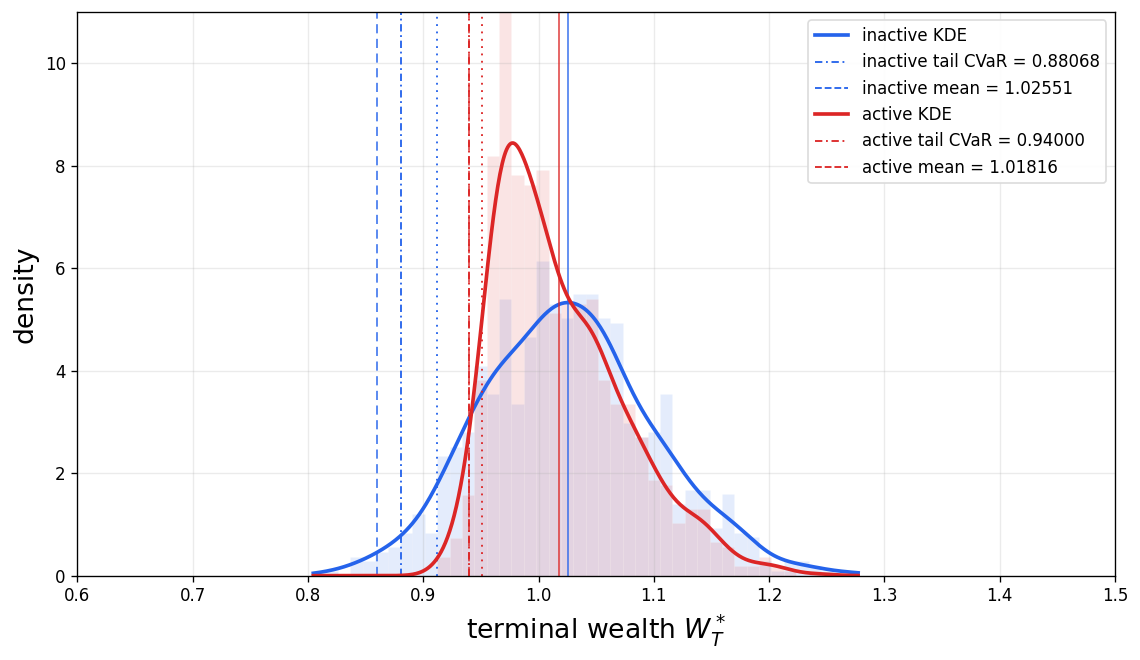

In [ ]:
def plot_terminal_wealth_distribution(cases, bins_count=44, figsize=(9.6, 5.6), save_path=None):
    x_low, x_high = terminal_axis(cases)
    x_grid = np.linspace(x_low, x_high, 500)
    bins = np.linspace(x_low, x_high, bins_count + 1)

    fig, ax = plt.subplots(figsize=figsize)
    for case in cases:
        color = CASE_COLORS.get(case["name"], "black")
        label = CASE_LABELS.get(case["name"], case["name"])
        terminal = case["wealth"][:, -1]
        density = gaussian_kde_1d(terminal, x_grid)

        ax.hist(
            terminal,
            bins=bins,
            density=True,
            alpha=0.12,
            color=color,
            edgecolor="white",
            linewidth=0.5,
        )
        ax.plot(x_grid, density, color=color, linewidth=2.2, label=f"{label} KDE")

        mean_w = float(np.mean(terminal))
        wealth_var = case["wealth_var"]
        wealth_tail_cvar = case["lower_tail_cvar"]
        floor = -case["cvar_limit"]
        ax.axvline(mean_w, color=color, linewidth=1.1, alpha=0.75)
        ax.axvline(wealth_var, color=color, linewidth=1.1, linestyle=(0, (1, 3)))
        ax.axvline(wealth_tail_cvar, color=color, linewidth=1.1, linestyle=(0, (4, 2, 1, 2)))
        ax.axvline(floor, color=color, linewidth=1.1, linestyle=(0, (5, 3)), alpha=0.8)

    legend_handles = [
        Line2D([0], [0], color=CASE_COLORS["inactive"], lw=2.2, label="inactive KDE"),
        Line2D([0], [0], color=CASE_COLORS["inactive"], lw=1.1, linestyle=(0, (4, 2, 1, 2)), label=f"inactive tail CVaR = {cases[0]['lower_tail_cvar']:.5f}"),
        Line2D([0], [0], color=CASE_COLORS["inactive"], lw=1.1, linestyle="--", label=f"inactive mean = {cases[0]['mean_terminal_wealth']:.5f}"),
        Line2D([0], [0], color=CASE_COLORS["active"], lw=2.2, label="active KDE"),
        Line2D([0], [0], color=CASE_COLORS["active"], lw=1.1, linestyle=(0, (4, 2, 1, 2)), label=f"active tail CVaR = {cases[1]['lower_tail_cvar']:.5f}"),
        Line2D([0], [0], color=CASE_COLORS["active"], lw=1.1, linestyle="--", label=f"active mean = {cases[1]['mean_terminal_wealth']:.5f}"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", ncol=1, fontsize=10, frameon=True, framealpha=0.92, edgecolor="0.85")

    # ax.set_title("Terminal wealth distribution under corrected GBM dollar exposure control", loc="left", pad=42)
    ax.set_xlabel(r"terminal wealth $W_T^*$", fontsize=16)
    ax.set_ylabel("density", fontsize=16)
    ax.set_xlim(0.6,1.5)
    ax.set_ylim(0.0, 11.0)

    # summary = "    ".join(case_summary_label(case) for case in cases)
    # ax.text(0.0, -0.19, summary, transform=ax.transAxes, fontsize=8, va="top")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_terminal, ax_terminal = plot_terminal_wealth_distribution(
    cases, save_path="final_oos_200x80x100_plot1_terminal_wealth.png"
)

## Plot 2. Dollar Risky Exposure Trajectory

This mirrors Plot 2 in `Portfolio_CVaR_Feedback.ipynb`: a single panel with
active/inactive mean dollar exposures, pointwise 10–90% ranges, and the
constant Merton dollar exposure `0.4`.

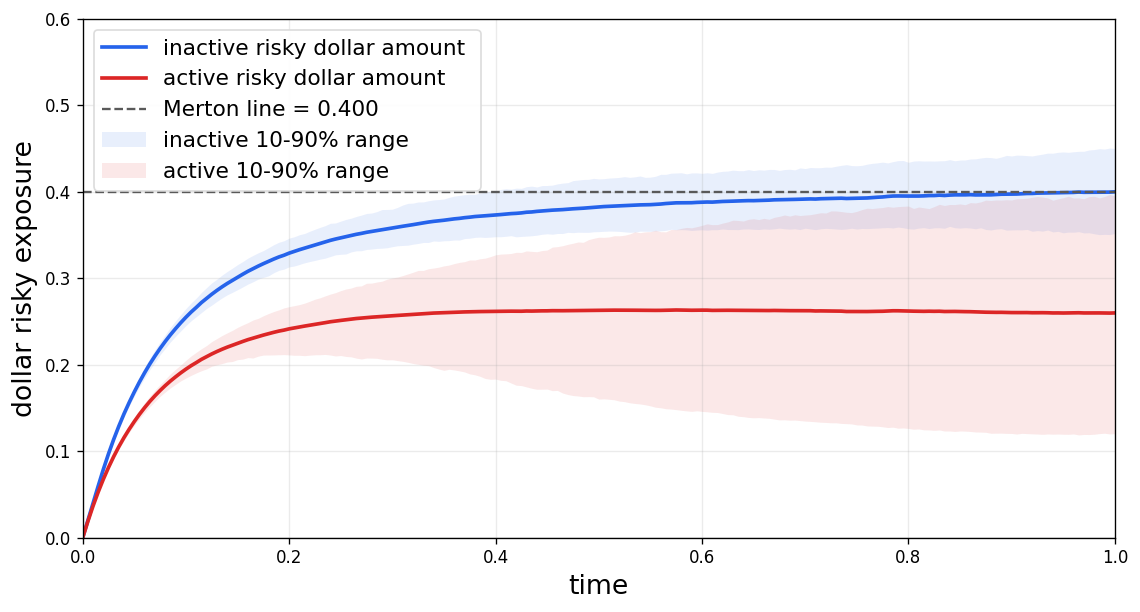

In [ ]:
def plot_exposure_trajectory(cases, figsize=(9.6, 5.2), include_band=True, include_sample=False, save_path=None):
    from matplotlib.patches import Patch

    fig, ax = plt.subplots(figsize=figsize)
    t = np.linspace(0.0, BASE_PARAMS.horizon, BASE_PARAMS.steps + 1)

    for case in cases:
        color = CASE_COLORS.get(case["name"], "black")
        label = CASE_LABELS.get(case["name"], case["name"])
        phi_paths = case["dollar_exposure_paths"]
        mean_phi = np.mean(phi_paths, axis=0)
        q10, q90 = np.quantile(phi_paths, [0.10, 0.90], axis=0)

        if include_band:
            ax.fill_between(t, q10, q90, color=color, alpha=0.10, linewidth=0)
        if include_sample:
            ax.plot(t, phi_paths[0], color=color, linewidth=0.9, alpha=0.32)
        ax.plot(t, mean_phi, color=color, linewidth=2.2, label=f"{label} risky dollar amount ")

    # ax.plot(merton_t, merton_line, color="0.30", linewidth=1.6, linestyle="--", label="Merton dollar exposure")
    ax.axhline(FRICTIONLESS_MERTON_X, color="0.35", linewidth=1.4, linestyle="--", label=f"Merton line = {FRICTIONLESS_MERTON_X:.3f}")
    ax.axhline(0.0, color="0.45", linewidth=0.8, alpha=0.7)
    ax.set_xlim(0.0, BASE_PARAMS.horizon)
    ax.set_ylim(0.0, 0.6)
    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel(r"dollar risky exposure", fontsize=16)
    handles = ax.get_legend_handles_labels()[0]
    if include_band:
        handles = handles + [
            Patch(
                facecolor=CASE_COLORS.get(case["name"], "black"),
                alpha=0.10,
                edgecolor="none",
                label=f"{CASE_LABELS.get(case['name'], case['name'])} 10-90% range",
            )
            for case in cases
        ]
    ax.legend(handles=handles, loc="upper left", frameon=True, framealpha=0.92, edgecolor="0.85", fontsize=13)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_exposure, ax_exposure = plot_exposure_trajectory(
    cases, save_path="final_oos_200x80x100_plot2_exposure.png"
)

## Plot 3. Lower-Tail CVaR Of Wealth Over Time

This uses the solver's simulated wealth paths, so the terminal CVaR agrees with the reported solver values.

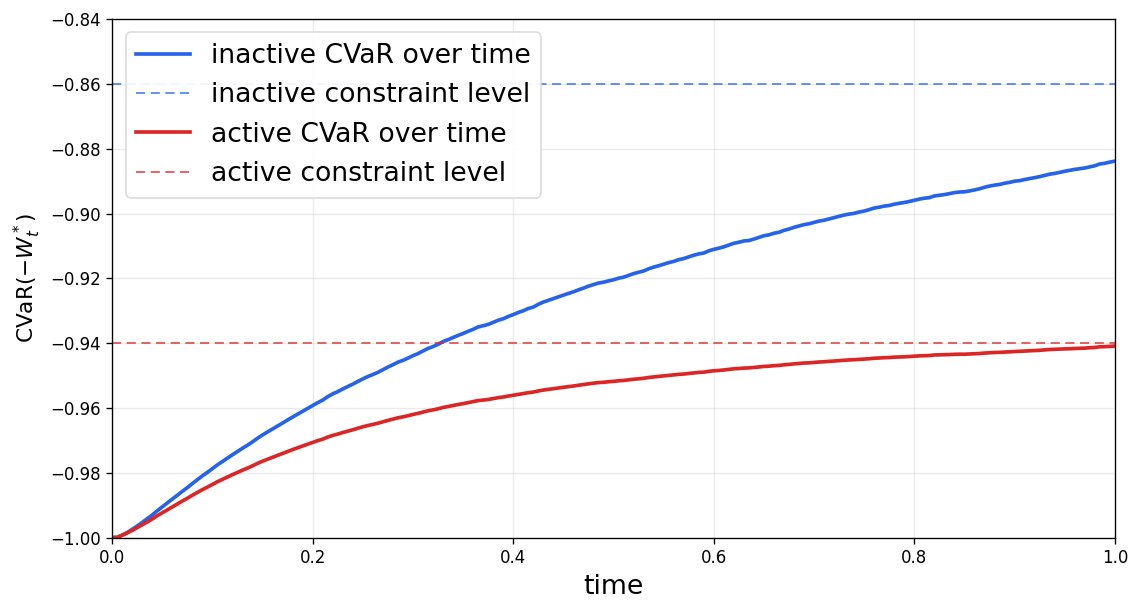

In [ ]:
def plot_wealth_cvar_over_time(cases, figsize=(9.6, 5.2), save_path=None):
    """Plot CVaR using only the final 50,000-path OOS validation sample."""
    fig, ax = plt.subplots(figsize=figsize)
    for case in cases:
        name = case["name"]
        color = CASE_COLORS.get(name, "black")
        label = CASE_LABELS.get(name, name)
        wealth_cvar = case["cvar_path_oos"]
        t = np.linspace(0.0, params.horizon, wealth_cvar.size)
        ax.plot(t, -wealth_cvar, color=color, linewidth=2.2,
                label=f"{label} CVaR over time")
        ax.axhline(case["cvar_limit"], color=color, linewidth=1.1,
                   linestyle=(0, (5, 3)), alpha=0.75,
                   label=f"{label} constraint level")
    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel(r"CVaR$(-W_t^*)$", fontsize=13)
    ax.set_xlim(0.0, BASE_PARAMS.horizon)
    ax.set_ylim(-1.0, -0.84)
    ax.legend(loc="upper left", frameon=True, framealpha=0.92,
              edgecolor="0.85", fontsize=16)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_cvar_time, ax_cvar_time = plot_wealth_cvar_over_time(
    cases, save_path="final_oos_200x80x100_plot3_cvar.png"
)


## Plot 4. Good And Bad Stock Paths

This cell chooses one good active-policy GBM stock path and one bad path. For
each path it plots the unaffected stock price `S_t^0`, controlled dollar
exposure `x_t = S_t^0 varphi_t`, and realized control `dot(x_t)`.

good path index=1376, S_T=1.5023, late phi=0.4000, Merton=0.4000
bad path index=4012, S_T=0.7136, late phi=0.0969


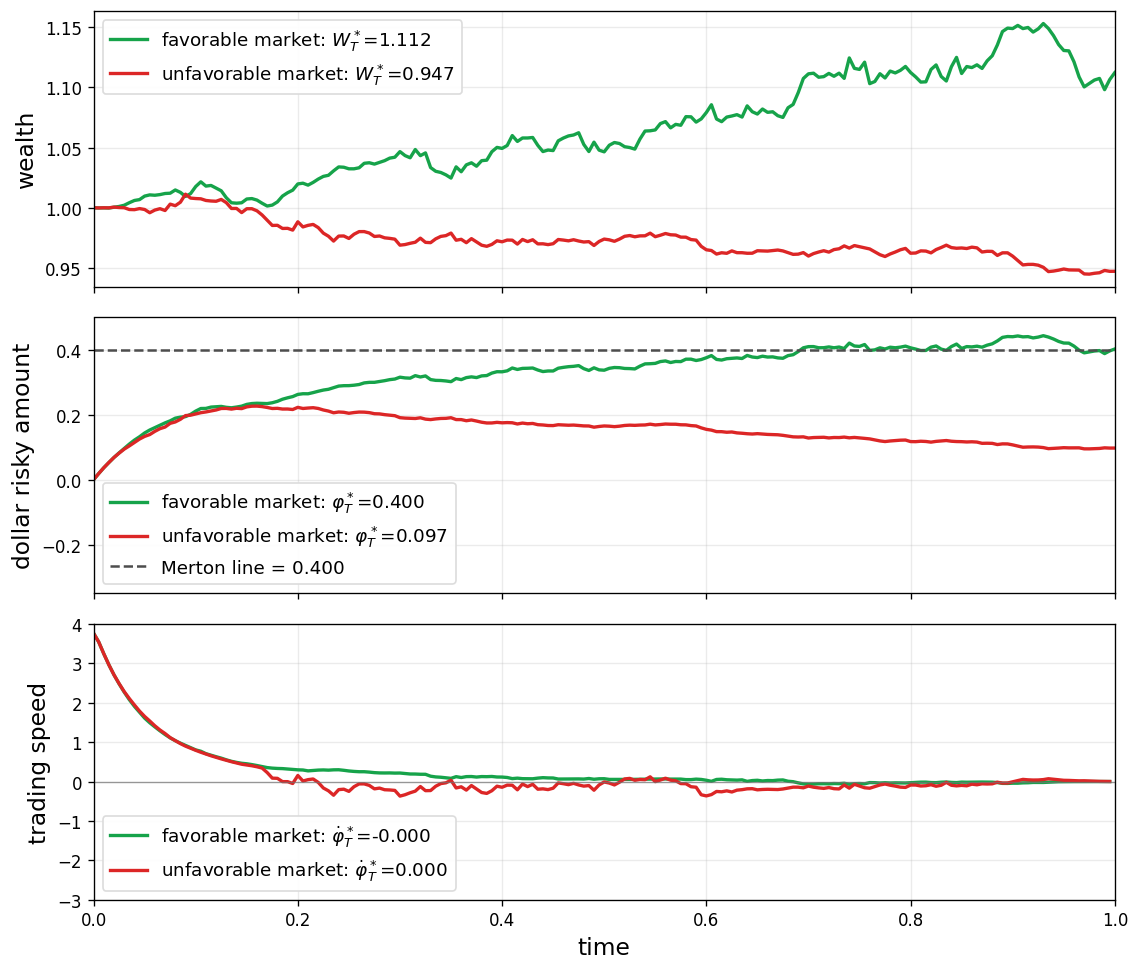

In [ ]:
def select_good_bad_market_paths(stock_paths, exposure_paths, merton_value, maturity_window=10):
    terminal_stock = stock_paths[:, -1]
    late_exposure = exposure_paths[:, -maturity_window:].mean(axis=1)

    good_candidates = np.where(terminal_stock >= np.quantile(terminal_stock, 0.75))[0]
    if good_candidates.size == 0:
        good_candidates = np.arange(terminal_stock.size)
    good_idx = good_candidates[
        np.argmin(np.abs(late_exposure[good_candidates] - merton_value))
    ]

    bad_candidates = np.where(terminal_stock <= np.quantile(terminal_stock, 0.25))[0]
    if bad_candidates.size == 0:
        bad_candidates = np.arange(terminal_stock.size)
    bad_idx = bad_candidates[np.argmin(late_exposure[bad_candidates])]
    if bad_idx == good_idx:
        order = bad_candidates[np.argsort(late_exposure[bad_candidates])]
        bad_idx = order[1] if order.size > 1 else bad_idx
    return int(good_idx), int(bad_idx)


def plot_good_bad_market_paths(
    active_case,
    path_count=8000,
    maturity_window=10,
    figsize=(9.6, 6.2),
    save_path=None,
):
    plot_params = replace(
        params,
        samples=path_count,
        seed=params.seed + 250000,
    )
    d_brownian_plot = generate_brownian_increments(plot_params)
    wealth_paths, exposure_paths, control_paths = simulate_feedback_policy(
        active_result.wealth_grid,
        active_result.inventory_grid,
        active_result.policy_grid,
        d_brownian_plot,
        plot_params,
    )
    stock_paths = stock_paths_from_brownian(d_brownian_plot, plot_params)
    merton_value = float(FRICTIONLESS_MERTON_X)
    good_idx, bad_idx = select_good_bad_market_paths(
        stock_paths, exposure_paths, merton_value, maturity_window=maturity_window
    )

    t = np.linspace(0.0, plot_params.horizon, plot_params.steps + 1)
    good_color = "#16a34a"
    bad_color = CASE_COLORS.get("active", "#dc2626")
    fig, (ax_stock, ax_exposure, ax_control) = plt.subplots(
        3, 1, figsize=(figsize[0], 8.2), sharex=True
    )
    for idx, color, label in [
        (good_idx, good_color, "favorable market"),
        (bad_idx, bad_color, "unfavorable market"),
    ]:
        late_exposure = float(exposure_paths[idx, -maturity_window:].mean())
        ax_stock.plot(
            t,
            wealth_paths[idx],
            color=color,
            linewidth=2.0,
            label=f"{label}: "+r"$W_T^*$"+f"={wealth_paths[idx, -1]:.3f}",
        )
        ax_exposure.plot(
            t,
            exposure_paths[idx],
            color=color,
            linewidth=2.0,
            label=f"{label}: "+r"$\varphi_T^*$"+f"={late_exposure:.3f}",
        )
        ax_control.plot(
            t[:-1],
            control_paths[idx],
            color=color,
            linewidth=2.0,
            label=f"{label}: "+r"$\dot\varphi_T^*$"+f"={control_paths[idx,-1]:.3f}",
        )

    ax_exposure.axhline(
        merton_value,
        color="0.30",
        linewidth=1.5,
        linestyle="--",
        label=f"Merton line = {merton_value:.3f}",
    )
    ax_stock.set_ylabel("wealth", fontsize=14)
    ax_exposure.set_ylabel("dollar risky amount", fontsize=14)
    ax_control.set_ylabel(r"trading speed", fontsize=14)
    ax_control.set_xlabel("time", fontsize=14)
    ax_exposure.set_ylim(-0.35, 0.5)
    ax_control.set_xlim(0.0, 1.0)
    ax_control.set_ylim(-3.0, 4.0)
    ax_control.axhline(0.0, color="0.45", linewidth=0.8, alpha=0.7)
    ax_stock.legend(
        loc="upper left", frameon=True, framealpha=0.92, edgecolor="0.85", fontsize=11
    )
    ax_exposure.legend(
        loc="lower left", frameon=True, framealpha=0.92, edgecolor="0.85", fontsize=11
    )
    ax_control.legend(
        loc="lower left", frameon=True, framealpha=0.92, edgecolor="0.85", fontsize=11
    )
    fig.tight_layout()

    print(
        f"good path index={good_idx}, S_T={stock_paths[good_idx, -1]:.4f}, "
        f"late phi={exposure_paths[good_idx, -maturity_window:].mean():.4f}, "
        f"Merton={merton_value:.4f}"
    )
    print(
        f"bad path index={bad_idx}, S_T={stock_paths[bad_idx, -1]:.4f}, "
        f"late phi={exposure_paths[bad_idx, -maturity_window:].mean():.4f}"
    )
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, (ax_stock, ax_exposure, ax_control), (good_idx, bad_idx)


active_case = next(case for case in cases if case["name"] == "active")
fig_good_bad, axes_good_bad, selected_good_bad_paths = plot_good_bad_market_paths(
    active_case, save_path="final_oos_200x80x100_plot4_good_bad.png"
)


## Plot 5. Trading-Rate Control Trajectory

Mean feedback control and its 10--90% pathwise range for the inactive and active CVaR cases.


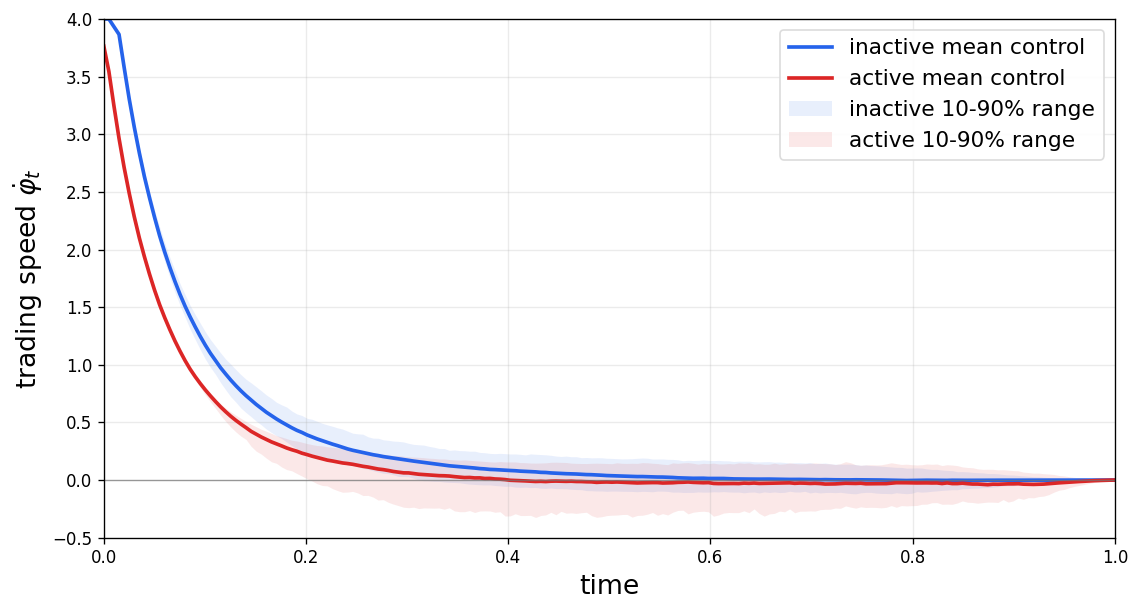

In [ ]:
def plot_control_trajectory(
    cases,
    figsize=(9.6, 5.2),
    include_band=True,
    include_sample=False,
    save_path=None,
):
    fig, ax = plt.subplots(figsize=figsize)
    t = np.linspace(0.0, BASE_PARAMS.horizon, BASE_PARAMS.steps)

    for case in cases:
        name = case["name"]
        color = CASE_COLORS.get(name, "black")
        label = CASE_LABELS.get(name, name)
        control_paths = case["trade_rate_paths"]
        mean_control = np.mean(control_paths, axis=0)
        q10, q90 = np.quantile(control_paths, [0.10, 0.90], axis=0)

        if include_band:
            ax.fill_between(t, q10, q90, color=color, alpha=0.10, linewidth=0)
        if include_sample:
            ax.plot(t, control_paths[0], color=color, linewidth=0.9, alpha=0.32)
        ax.plot(
            t,
            mean_control,
            color=color,
            linewidth=2.2,
            label=f"{label} mean control",
        )

    ax.axhline(0.0, color="0.45", linewidth=0.8, alpha=0.7)
    ax.set_xlim(0.0, BASE_PARAMS.horizon)
    ax.set_ylim(-0.5, 4.0)
    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel(r"trading speed $\dot\varphi_t$", fontsize=16)

    handles = ax.get_legend_handles_labels()[0]
    if include_band:
        handles += [
            Patch(
                facecolor=CASE_COLORS.get(case["name"], "black"),
                alpha=0.10,
                edgecolor="none",
                label=f"{CASE_LABELS.get(case['name'], case['name'])} 10-90% range",
            )
            for case in cases
        ]
    ax.legend(
        handles=handles,
        loc="upper right",
        frameon=True,
        framealpha=0.92,
        edgecolor="0.85",
        fontsize=13,
    )
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_control, ax_control = plot_control_trajectory(
    cases,
    save_path="final_oos_200x80x100_plot5_control.png",
)
